# The Mathematics of Eigen Times — Python 3 teaching notebook

Alexy Khrabrov · Notebook edition 1.0.0 · Companion text 1.1.1

This notebook includes **the complete companion text**, its figures as embedded
attachments, and executable lessons after the corresponding explanations. Read
from top to bottom. Use **Restart Kernel and Run All** for a clean run; then edit
the small input arrays and rerun a lesson to explore what changes. Later cells
depend on earlier ones. Outputs saved here show a verified run, but rerunning is
the way to check your own edits.

Examples use synthetic or explicitly frozen numerical inputs. Dated catalog
counts, archive-wide measurements, model labels, and live-site journeys in the
original text are historical evidence, not claims that this notebook recreates
or refreshes the production archive. No credentials, remote API calls, paid news
access, or live network connection are needed to execute the lessons.

The companion's original diagrams remain embedded reference figures. Lesson
outputs recompute the arithmetic from editable inputs. Exercise suggestions
accompany the examples; assertions check mathematical identities and reference
results. When deliberately changing a fixture, examine and update its expected
results as part of the exercise.

The setup cell defines reusable numerical helpers. Their operations are
introduced in the relevant chapters; you may run it now and return to its code
later. The OCaml edition computes in OCaml and does not call Python. The Python
edition uses NumPy and, where needed, SciPy/Matplotlib.

For environment installation and verification commands, see the included
`README.txt`. Python needs the `math-companion-python` kernel from the teaching environment;
OCaml needs the `ocaml-jupyter` kernel (an installed differently named OCaml
kernel can be selected in Jupyter). Both notebooks retain the same full text.

Original reader: [The Mathematics of Eigen Times](https://firstpair.org/read/eigentimes-math/).
Manuscript revision: `ef4d3687`. Notebook source revision:
`fe8e8983`. The manuscript and lesson SHA-256 hashes are in notebook metadata.


In [1]:
import json, math
from itertools import permutations
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True)
RESULTS = {}
def record_result(key, value):
    RESULTS[key] = float(value)
    print(f"{key} = {value:.12g}")
def assert_close(actual, expected, tol=1e-9):
    np.testing.assert_allclose(actual, expected, rtol=tol, atol=tol)
def cosine(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        raise ValueError("A zero vector has no direction or cosine")
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
def covariance(x, weights):
    z = np.sum(weights)
    assert z > 0 and np.all(np.asarray(weights) >= 0)
    mu = np.average(x, axis=0, weights=weights)
    centered = x - mu
    return mu, centered.T @ (centered * np.asarray(weights)[:, None]) / z

FIXTURES = json.loads(r'''{"covariance_rows": [[1.603514377052519, 0.040872183525761295, 0.22334908743269138], [-1.0051743504605932, -0.7842693549624872, 0.03324028448802799], [-2.4573908734799144, -1.8136124246981904, -0.16164448946752474], [2.8855947723122193, 2.7354074864587834, -0.00786980488752087], [-0.7186921624840137, -0.6843218369803262, -0.21862573194657864], [-0.8282057215673181, -0.08193764347752813, 0.026353351442947745], [0.5203539586271007, 0.5878615901339874, 0.10519730293795714]], "cloud_points": [[-0.10221718120007706, 0.1824580260179311], [-0.21059561957681602, -0.8414442506352652], [-0.5191878964493616, -1.101291639430476], [-0.35448638295019214, 0.8786202772897801], [-0.7206131528052667, -0.9175700883647336], [0.8083639976088928, 0.7551775059467838], [0.5265049342645562, -0.4481106009911696], [-0.2990883250528124, 0.38932815610374333], [-2.4009071650239786, -1.7560508139766748], [-3.1709776110996613, -2.8730857230357176], [-3.426694629612436, -2.168424965771469], [-2.5097523974959834, -1.2297458514714497], [0.3640767614127511, 0.0591053325245737], [-4.606528744995511, -3.095000894751539], [-0.1320648569159165, 0.015338882307964636], [-2.7480865305551276, -1.9727718737065691], [-1.581236201507552, -1.566702503670915], [2.3039204854891886, 0.6774466054327175], [-0.3714986234299571, 0.5003589889622929], [-1.0728124785591848, -0.7096761842121236], [0.18813883838566206, 0.16017620333675822], [-2.36069390744205, -1.3014038474299205], [3.1304069628129985, 0.5567991477032763], [1.5955700176845709, 1.0176754896317841], [-1.9223110367792808, 0.5070706495803449], [1.8720509206197278, 0.11145542430327242], [-0.05986887064190433, 0.43156733233798616], [-0.59869684945349, 0.20633201004156276], [-0.36026916218233884, 0.33132828464265435], [2.977235426094502, 1.1727763791974157], [0.5491886853795614, -0.05741282030507955], [0.657996974633428, -0.5797031818980515], [-1.035049187371661, -0.756169243751167], [1.3115474569248207, 1.6828942053102516], [-2.243534291897961, -1.9376069048403897], [1.9298634794971758, -0.4962465388377105], [-0.8484066885110154, -0.5684639158080734], [2.153643821989627, 1.8006453789691506], [-0.4944237326825699, -0.583372023503607], [-1.0099215502284555, 0.6483756743755394], [-0.7092089062595975, -0.6549238884986399], [0.7140420523848006, 0.3146347825839353], [0.014046563097374133, -0.8923799640055535], [0.1333020832184457, -0.2815804402587346], [1.9931908361812447, 1.6786544177903697], [-0.27993311899620227, 0.37862648757894496], [-1.0157826901135476, 0.26396120118779914], [-0.21447136872713363, 0.34771724044907726], [-2.5808199739599806, -1.20981895933607], [-2.5040957045794285, -3.090877129066228], [-0.26513170145925147, -0.880476684305717], [-0.47310226424310126, 1.5412694599787073], [-1.3662652335870404, -1.293141197025446], [0.21879242573079083, 0.5248177650077055], [-0.2640230802147031, -0.3188853006826372], [1.1564040086122704, 1.0878865055376254], [-1.941703504162886, -1.1850445386795856], [0.4363000939099223, -0.6004317958885719], [0.7953447435888924, -0.23428546246160406], [1.784574749692612, 1.1861193784628725], [0.37701163137686006, -0.2600547632053291], [0.47322913716121057, -1.3415401342470519], [-2.282614675025881, -1.0245882790543104], [-4.351777872646204, -1.8281946053402092], [-3.591619067223498, -1.461957785780962], [-1.8835350799751567, -0.4578084883137461], [0.7873877884363304, -0.7876103414578994], [1.8753505060580988, 2.2480521395645687], [-0.02950448937730597, -0.23843831174804114], [0.0367158347082315, -0.7670083414277579], [2.283101068969156, 0.879334692661045], [0.1801229059144224, -0.5372198404941053], [-0.7456256566863603, -1.4632601179611835], [2.4489693626100797, 1.2893656181231006], [1.8356642428245769, 1.070591388197139], [-1.2086765690293344, -0.9618862944158959], [-1.0701691925082983, -0.6114292080934267], [-0.6100067554082913, -0.5946114012512036], [-2.3441414597793897, -2.0055565017314425], [3.386334510169802, 1.4125497916839285], [-2.126382612118529, -0.9550099450230515], [3.1901221505506565, 0.6665440309441125], [-0.17606908534808743, -0.6125355308405226], [-3.612417071159065, -1.491595781663916], [-0.06967130937445931, 0.017521006025096868], [-1.5925203197809064, -0.5518443728142273], [-0.9774833276953301, -0.6798575506244023], [-1.6858844340315369, -1.9563099901665353], [2.7220165779454684, 1.1616691512737796], [0.5675523686244296, 0.30036402955195635], [-0.6627081555512883, -0.7931946961485207], [1.3061222290701289, 0.5100933407160003], [-0.2963164474459575, -0.15311690985897353], [2.003370563702783, 1.7066970063876854], [0.9262014006374072, 0.0792132940577222], [-2.9653395173816945, -0.9445436622315789], [1.8905770329230547, 0.9777919139263067], [0.7589223111437973, 1.0697969011568267], [1.2611348570885201, 1.4728619440524882], [-1.3983087556799259, 0.41722414659706314], [-2.676681841592647, -0.8488605111216234], [0.6353003122727642, 1.0729287288145366], [3.0604357256265593, 2.9668063811415193], [-1.5908199925034003, -2.2833973389208015], [1.9116370354277128, 0.28325938884556084], [-0.31754005671946217, 0.49541180162735315], [-2.3933614235523164, -3.0872847587485923], [0.4784959239699502, 0.31213643795323065], [-0.4818049164385426, -0.24702291947242594], [-1.1097793853874947, -1.8640743917323288], [0.022577905909501834, -0.7723874240371823], [-3.3082408418648237, -1.5012765968245605], [-0.25926508615796096, 0.17890633679673731], [-1.654539435299829, -1.4871513772084994], [-1.5931079568317013, -1.6364453965939763], [0.6463432016347562, -0.2597044262607638], [0.5594828195127551, 0.5976390014512284], [4.345926061114317, 1.3833435984847697], [1.7230020202896152, 0.9224434217887651], [0.4807221117236105, -0.8943659344034823], [-1.1369060136701161, -0.05567379688124163], [-0.1855114335894367, -0.04158960851429886], [-0.9579890789939025, 0.38013236327117184], [0.7292347505716333, -1.3575509336262637], [-0.6294964894620685, -1.9547993191532096], [-6.009281814233066, -3.897947608933419], [2.524280789697332, 1.4954807601261182], [-1.9047546594935891, -1.8600692663854568], [2.098938196163381, 1.3392306153980926], [0.11016246371459984, 0.020389678632400845], [-0.20872965198875598, 0.5304915131342202], [0.9772854519753437, 0.7385880520475229], [-2.1658191467653922, -0.8373119711929132], [-1.686511760980066, -0.08956308558704147], [-2.3735097207547406, -1.4815841869803328], [0.449606524441017, -0.811117803427892], [2.769654245446711, 2.7794933604559633], [-1.1533480994854965, -0.04211104395808172], [1.6362206236780692, -1.1678425460535196], [0.49854272287960716, 0.23824994585018786], [0.535456574657748, -0.5612816372660836], [-0.45078447863077453, -0.40434538311783336], [2.146574032092706, 1.50963926994165], [-0.5457232532722815, 0.9207782686476498], [-0.9215887809564952, -0.8468522986579334], [-4.0105702291983505, -1.0472106455971637], [1.5164031072264672, 1.6165751935839283], [1.2358706981027061, 0.8025623236670211], [0.49876387683976264, 0.08426695673575244], [-0.40691717407406897, -0.19104065321232702], [2.685931313418725, 1.9998803503991829], [0.09140571882085309, -0.4155439024390628], [-1.77078136112939, 0.27308994196077374], [0.941726274509869, 0.5983063843256085], [-0.271396299097751, -1.053127926448516], [-0.4331686881367212, 0.4560793232332167], [-0.6683489968741163, -0.5695494663112942], [-0.4594850284007392, -0.17669973182419613], [-2.9527039337092917, -1.8950146335877014], [-1.9374468533190996, -0.40358389296478775], [-1.6701540276164846, -0.49784254458783855], [3.0142021246405593, 1.486773567838239], [-1.2131579873293115, -0.5456842376808834], [0.3438999047692216, -0.6045798292581163], [0.1727388121151948, 1.7288530301162583], [-0.4207627302049011, -0.4069103525229023], [-2.1025438488954498, -0.9559881322756387], [-1.988382936203422, -2.042715118306252], [2.7550021755662737, 0.8587322530690971], [1.5267375750301866, 2.1135862552811044], [0.3003962691084372, 0.6207348123977221], [3.7883925466717674, 2.028215782371075], [-0.6561969137602967, -1.4726591121403823], [-0.438237813406655, 0.9425613121421399], [2.1580066853204922, 0.484442456115413], [-1.453249056506628, -1.246550486942409], [0.6287044846302197, 0.1970314526535569], [0.30473086001421645, 0.41578802777077556], [-0.5551792557342903, -0.3530051031451035], [0.42300073941067845, 0.17634768745205273], [0.3045295722599965, 1.6880311144122924], [1.1083249900422885, 0.6850028589401409], [-3.348272415681342, -1.6195440012509617], [-3.2157585765414782, -2.995527772330503], [1.381124197112613, 1.368235429900749], [0.31283172765939543, -1.201572039260716], [-0.4699555370517239, -0.8199466068478374], [0.4231388951407209, 2.069201217930637], [0.6860669843442304, -0.2338087272792828], [-2.2105671974300503, -1.3216120338401807], [0.06619543287693531, -0.8925439044316539], [0.6245062303988677, -0.5697134836485438], [1.746921215886298, 1.8675156928738565], [2.2326464002878152, 0.9058485666699951], [1.0265176597532533, 0.4859097370402545], [-0.622085489439434, -0.6332893958104674], [-1.9709378835319529, -2.3049826485106504], [1.580305323872667, 0.7578159674355525], [0.06174608603198932, 0.8453219867856177], [-3.027615365542538, -2.3817993391748336], [0.19682456760755174, 0.430563159972256], [-1.0786360484081383, 0.20912485695339272], [0.8255399446688558, -0.5041393969936556], [-2.0552580360196178, -0.5355492733086347], [1.5483890472559338, -0.6410300913237819], [2.358427341820077, 1.8450181550026146], [2.693707445726159, 1.2450709891403018], [-0.16913603974501445, -1.0081551596328804], [4.8949089806540345, 2.6842590556623382], [3.2512093201122725, 1.3538863166846384], [0.8971327667424822, -0.8329782868671745], [-1.0737741075743932, 0.17521585559699426], [-2.7601719160257843, -0.7269147923463899], [1.0079071581558932, -0.2619000175051309], [-0.7949981681050069, -0.8300507751909083], [0.09330337787913652, -0.3794912779514722], [-1.469589448468319, -1.0946631725257085], [-1.5051534207211195, -1.9113126520047423], [-0.40079450592006705, 0.4822199246156435], [-2.9150722996260616, -1.6801821718274221], [-0.8963319643018355, -1.3073147545069093], [1.8073765043351802, 0.6246577380295598], [3.127591881599004, 1.175379361216051], [0.8159342515002858, 0.2873691927194855], [-1.6422907566662632, -0.47316492880929456], [-0.5064051631884311, 0.1951961503284192], [0.2899332667625212, -0.7102617805918904], [-0.21265233593326865, -0.08078001984656445], [2.1433113391915697, 0.5049128611589775], [0.5277241210559915, -1.0870963444247501], [1.6197800305467014, 0.06102815551823443], [-3.4208512219816907, -2.0228937711614967], [2.6401692099997747, 0.2921066058179296], [-1.8128399939006232, -1.6474256002803465], [-2.284779897204411, -1.0124303778347787], [-1.2857114209524645, -1.325499253234493], [1.3757761663707206, 0.183629534205748], [1.1645416398056367, -0.11281285743775954], [-1.6670267904583018, -2.446034363895019], [3.6581582303777447, 1.8531763452710994], [0.4756228137861599, 0.2495039402565884], [0.2873778116639922, 0.20607876006196166], [3.999266056979501, 1.4692229688177305], [-2.6131779645182753, -2.3266762630669056], [-2.8043989184126015, -1.0153582315557714], [1.8994908551785739, 0.3196494522843841], [-2.5249571218455396, -1.7445633944678096], [3.637296255943982, -0.17903685481889614], [1.379873082224473, -0.07285250273960506], [2.3594390112753003, 0.49094719989270974], [-0.01659250020050235, -1.2270905863778319], [-2.346969981140222, -0.23486329101779482], [1.7039962263793893, 0.6591381779215179], [-0.9950685344109115, -2.105249170285928], [-0.7392006299231053, -0.45175648435059357], [-0.12731788541193206, -0.14931812822603108], [-2.114138537976666, -1.2741669977835044], [-0.5253793973118298, 0.7398209394395389], [3.6045510652607615, 1.9703616156422357], [-1.4372651803202472, -0.8823298689095894], [-0.8978221770393395, -1.1184599843252874], [0.2534130036024478, -0.696984865995501], [1.1911588988065236, 0.6037219724613837], [0.5403588113650145, 0.16410763458205943], [-1.0538199720266601, -1.3746498343296263], [-0.26000538629800724, -0.593671879718259], [0.44719298850396455, 0.25460488924470126], [-2.6190354079856273, -1.45784729740702], [-2.342725548025273, -1.8508661580499177], [0.16552670005671358, -1.5818565350659712], [0.12150093146087515, 0.19218698412673835], [-0.1525654796552297, -0.43105528882458694], [-0.37002175930722175, -1.0029596174496862], [-0.32043408627925324, -0.6316735088941966], [0.5961317656318266, -0.6291147782555113], [0.39873244865642893, 0.34597073994975003], [-0.11599173149638432, -0.42197288937675953], [1.6349594298637544, -0.401537273969372], [0.7922183206336147, 0.6538323058142169], [0.40574494261206456, 0.5440848316340944], [-1.1545488341267263, -0.8762981484816394], [1.0630354013278467, 0.961825332007735], [0.9238527993435789, -0.6906238192301594], [0.6154977456882025, 1.3006299380100415], [1.8418252403253845, 1.25241967448225], [-3.2976670166157542, -1.142059036635889], [0.6058241131298298, -1.697238545958197], [1.2409367499679087, -0.48965292625211665], [-2.2478154369502668, -1.811008010022779], [2.5544077090552237, 1.175037247355424], [-0.09548046909115497, 1.357740009637939], [3.073208287006047, 1.6907780603492946], [-0.018854627503903702, -1.030035324271703], [-1.4719957566943171, -0.5060440872786486], [0.7153849832185847, 0.5021322140560489], [2.1656805203515135, 0.6260585990702463], [-0.36277516624954953, 0.38160833086122], [0.7381164059757844, 1.291786870352645], [0.8647163622335134, 0.24915711624168818], [1.0409772553053926, -0.20937955055798105]], "term_blocks": [[[0.0, 0.0, -0.0, -0.0, -0.0], [-0.9916465549964624, 0.060143602597438485, 0.0, -0.49220651855132963, -0.6204748998199404], [0.0, 0.0, 0.0, -0.0, -0.0]], [[-0.0, -0.0, -0.0, -0.0, 0.0], [-0.8075346753318965, -0.0, 0.0, -0.0, -0.11170194958415963]], [[0.7622597120847118, -0.0, 0.0, 0.5766895836701853, -0.0], [0.0, -0.0, 0.0, 1.438522591656152, -0.6756622510056528], [0.0, -0.0, 0.12726841122583082, -0.0, -0.0], [-0.0, 0.8987638721004078, 0.0, -1.323527792484255, -0.7946423659870495]]], "score_blocks": [[[-0.024143613009932233, 0.6683810232673438, -0.3398695517131494], [1.052126358426947, -0.005399560671626605, 0.5833823541804138], [-1.2908932453234871, 0.34668004887842974, -1.6882041173665416]], [[-2.0353289449399323, -0.3044768777114372, -0.8999276075985952], [0.16405279571222256, 2.2447566264860495, -0.8317231814120817]], [[-0.6239435864439059, 0.2054039460646989, 0.49301329141235634], [-0.1764060659057582, -0.20593033025321647, 0.7024629551205442], [0.5199076370338984, -1.0336758320736887, -0.07918131861584184], [0.035286848661474135, -1.0544846220491104, 0.25983910067436333]]], "expected": {"terms": ["troops", "border", "ceasefire", "bank", "rate", "mortgage", "rise"], "singular_values": [1.641, 1.506, 0.824, 0.553, 0.232, 0.0], "eigen2d": [4.055, 0.438], "varimax_angle": -33.28, "rank2_error": 0.416}, "threshold_archive": {"embed": {"bins": [-0.2, -0.15, -0.1, -0.05, -0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0], "same": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 19, 91, 368, 944, 1884, 3122, 3508, 2160, 785, 214, 74, 21, 10], "diff": [0, 0, 0, 0, 0, 0, 0, 3, 38, 275, 1178, 3623, 8590, 13716, 12758, 7263, 3206, 868, 88, 0, 0, 0, 0, 0], "n_same": 13201, "n_diff": 51606, "same_median": 0.6526788473129272, "diff_median": 0.4945347458124161, "diff_p99": 0.6663863658905029, "same_p10": 0.5460114479064941}, "cluster_sizes_2022_02_24": {"0.6": {"clusters": 10, "largest": 143, "singletons": 9, "n": 152}, "0.66": {"clusters": 47, "largest": 104, "singletons": 45, "n": 152}, "0.72": {"clusters": 73, "largest": 62, "singletons": 67, "n": 152}, "0.78": {"clusters": 111, "largest": 34, "singletons": 103, "n": 152}, "0.82": {"clusters": 133, "largest": 8, "singletons": 125, "n": 152}, "0.9": {"clusters": 151, "largest": 2, "singletons": 150, "n": 152}}, "lsa": {"bins": [-0.2, -0.15, -0.1, -0.05, -0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0], "same": [126, 286, 387, 406, 519, 600, 696, 808, 858, 884, 957, 938, 882, 838, 751, 710, 625, 523, 446, 395, 263, 166, 64, 18], "diff": [3643, 6193, 7570, 7168, 5813, 4316, 3232, 2474, 1923, 1445, 1161, 921, 765, 600, 480, 410, 335, 252, 196, 118, 83, 26, 5, 0], "n_same": 13201, "n_diff": 51606, "same_median": 0.3512640595436096, "diff_median": -0.00955875450745225, "diff_p99": 0.6806725412607193, "same_p10": 0.006583633366972208}, "episode": {"bins": [-0.2, -0.15, -0.1, -0.05, -0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0], "continued": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 15, 78, 95, 106, 75, 28, 11, 7, 3, 5], "new": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], "n_cont": 424, "n_new": 0, "new_p95": null}}, "episode_archive": {"bins": [-0.2, -0.15, -0.1, -0.05, -0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0], "raw": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 21, 105, 165, 175, 111, 50, 19, 16, 8, 6], "centered": [0, 0, 0, 0, 0, 1, 15, 72, 150, 129, 76, 66, 46, 26, 29, 26, 8, 9, 9, 3, 8, 1, 3, 1], "n": 678, "raw_median": 0.6606759428977966, "centered_median": 0.28916847705841064, "centered_p90": 0.5496706187725069}}''' )

covariance_rows = np.array(FIXTURES['covariance_rows'])
cloud_points = np.array(FIXTURES['cloud_points'])
term_blocks = [np.array(x) for x in FIXTURES['term_blocks']]
score_blocks = [np.array(x) for x in FIXTURES['score_blocks']]
print('Teaching setup ready; raw frozen figure inputs embedded, no network or production database required.')

Matplotlib is building the font cache; this may take a moment.


Teaching setup ready; raw frozen figure inputs embedded, no network or production database required.


# Preface

This is the companion to *Eigen Times: A Newspaper in the Eigenbasis of the News*. That article states the mathematics compactly and reports what came of it. This one slows down. It assumes a reader who remembers that a matrix is a grid of numbers and a vector is a list, but not much more, and it builds everything Eigen Times uses from there: how text becomes vectors, what a covariance matrix is and why its eigenvectors are the "eigen‑news", what the singular value decomposition does and how latent semantic analysis is one, why eigenvectors have to be rotated before they can be named, how the whole computation is arranged as sums over blocks so that a 175-year archive fits in a laptop's memory, and how a new story is measured against the basis. The last chapters explain every threshold the system uses—for clustering, for threading, for the daily spectrum, for "different this time"—with the actual distributions from the Eigen Times data that led to each choice.

Every matrix in the figures is drawn as a grid of coloured squares: blue for positive entries, rust for negative, darker for larger. Every worked example was computed by the same script that draws the figures (`scripts/figures.py` in the source repository), so the numbers in the text are the numbers in the pictures.

**Version 1.1.1.** This correction defines notation and technical terms before use, makes vector shapes explicit, and distinguishes full rotations from projections and marginal scaling from whitening. It also corrects conceptual figure labels and distinguishes implemented rules from illustrations. The computed example data, reported measurements, threshold values, and evidence dates are unchanged; corrected prose and labels now agree with those examples.

# Why a newspaper needs linear algebra

Eigen Times starts from a claim about news: that most of it recurs. Wars, scandals, market shocks, elections, disasters happen again and again with different names attached. If that is true, then the enormous variety of news articles should be mostly explained by a small number of recurring *directions*, and each day's news should be describable as "so much of this recurring thing, so much of that one, plus a remainder those directions do not capture."

Linear algebra is the mathematics of exactly that sentence. A vector is an ordered list of numbers, and a nonzero vector specifies a *direction*. "So much of" is a coordinate. A *subspace* contains all weighted combinations of some directions; a low‑dimensional one uses relatively few independent directions. A *residual* is what remains after a reconstruction. The covariance and eigenvector chapters will make "which directions explain the most?" precise.

The chapters follow the pipeline. Text becomes vectors (§2). Vectors are stacked into matrices, and matrices are multiplied (§3). The covariance of a million article vectors is computed and its eigenvectors found (§4). The singular value decomposition works directly on the data matrix and gives us latent semantic analysis (§5). The eigenvectors are oriented and rotated into axes with names (§6). A new story is projected, and what is left over is measured (§7). Then come the thresholds (§8–§9), matching axes across bases and nights (§10), streaming the calculation (§11), and the shapes of everything (§12).

### Laboratory: A recurring direction and its remainder

**Editable synthetic fixture.** Let the three rows of `news` be three observations
in two coordinates. `direction` is a unit (length-one) column direction and `scores` are its
coordinates. `rebuilt` contains their projections; `remainder` contains the lost
parts. We check perpendicularity, rather than claiming that every story is fully
represented. All later vector formulas use columns mathematically; array rows
store observations for convenient computation.

In [2]:
news = np.array([[1.,0.],[2.,0.],[3.,1.]])
direction = np.array([1.,0.])
scores = news @ direction
rebuilt = np.outer(scores, direction)
remainder = news - rebuilt
assert_close(remainder @ direction, 0)
print('scores:', scores, '\nremainder:', remainder)
record_result('recurrence_residual_squared', np.sum(remainder**2))

scores: [1. 2. 3.] 
remainder: [[0. 0.]
 [0. 0.]
 [0. 1.]]
recurrence_residual_squared = 1


# Text as vectors

## Counting words

The oldest way to turn a document into numbers is to count its words. Let $p$ count the terms in a fixed vocabulary; a document becomes a row of $p$ counts. A *corpus* is the collection of documents being analysed. Six tiny "articles", labelled d1 through d6, and seven retained terms are enough to see the construction:

```
d1  troops shell border town
d2  ceasefire troops border
d3  bank raises rate
d4  rate rise hits mortgage
d5  troops ceasefire talks border
d6  bank mortgage rate rise
```

Terms that occur in only one document (*shell, town, raises, hits, talks*) are dropped in this example—they provide no shared term for connecting documents—leaving *troops, border, ceasefire, bank, rate, mortgage, rise*. The count matrix is the left grid of Figure 1, after the weighting rule below.

### Laboratory: Build the exact six-document count table

These are the six articles printed above, with the retained vocabulary in the
same order as the figures. `counts[i,j]` is the number of occurrences of term
`j` in document `i`. Change a document and rerun from here to explore the effect.
The vocabulary stays fixed so both languages continue to describe the same
coordinates. The count table is computed from text, not copied from a figure.

In [3]:
docs = ['troops shell border town', 'ceasefire troops border', 'bank raises rate',
        'rate rise hits mortgage', 'troops ceasefire talks border', 'bank mortgage rate rise']
terms = ['troops','border','ceasefire','bank','rate','mortgage','rise']
counts = np.array([[doc.split().count(term) for term in terms] for doc in docs], float)
print(terms, '\n', counts)
assert counts.shape == (6,7)
record_result('retained_occurrences', counts.sum())

['troops', 'border', 'ceasefire', 'bank', 'rate', 'mortgage', 'rise'] 
 [[1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1.]
 [1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1.]]
retained_occurrences = 17


## TF‑IDF

TF‑IDF means *term frequency–inverse document frequency*. Raw counts favour long documents and give common and rare words the same weight per occurrence. Let $t$ identify a vocabulary term, $N$ count documents, and $\mathrm{df}(t)$ count the documents containing $t$. The operator $\ln$ is the natural logarithm; it grows more slowly than its positive input. For a positive within-document count, the damped term frequency is $\mathrm{tf}=1+\ln(\text{count})$; an absent term gets frequency zero, avoiding the undefined $\ln(0)$. The inverse document frequency, denoted $\mathrm{idf}(t)$, rewards rare terms:

$$\mathrm{idf}(t) = \ln\frac{N + 1}{\mathrm{df}(t) + 1} + 1,$$

Multiply each term's damped frequency by its inverse document frequency. In the example *troops* appears in three of six documents and gets idf 1.56; *ceasefire* appears in two and gets 1.85. The *Euclidean length*, or *norm*, of a row is the square root of the sum of its squared entries. Dividing a nonzero row by that length makes it a unit row, with norm 1. This normalization makes lengths comparable; an all-zero row cannot be normalized this way.

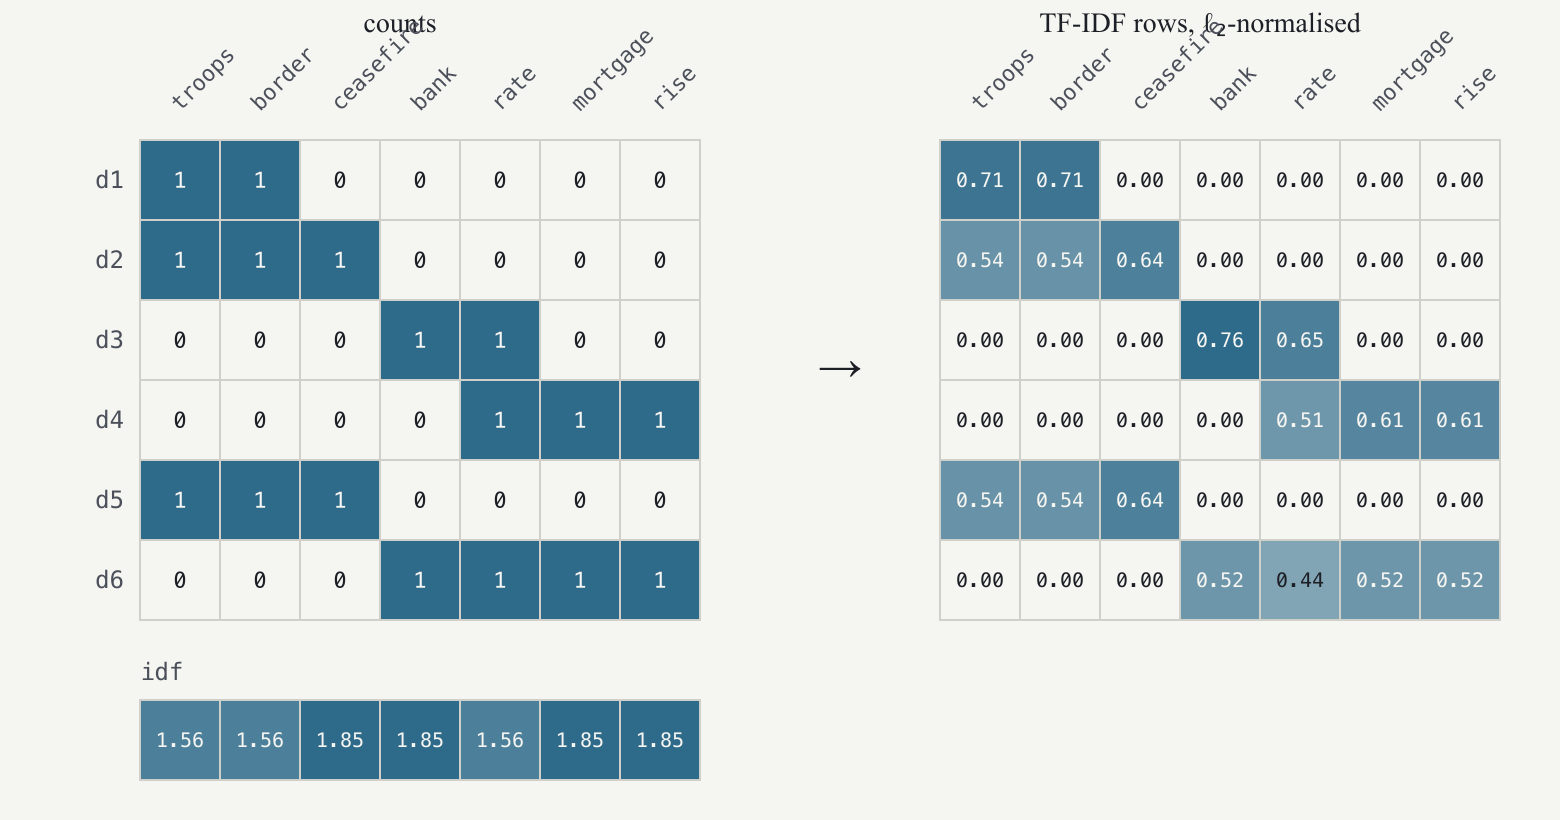

*From counts to TF‑IDF. Left: word counts for six documents over seven terms. Bottom: the idf weight of each term. Right: the TF‑IDF rows, each scaled to unit length.*

Eigen Times builds this representation over 1,093,166 articles and a 50,000‑term vocabulary, keeping terms that occur in at least 20 documents and at most 30% of them. The result has 149 million non‑zero entries out of 55 billion cells—it is 99.7% zeros. *Sparse* storage keeps only nonzero entries and their positions; *dense* storage allocates every cell. The algorithms of §5 avoid forming this full matrix densely.

### Laboratory: Damped counts, inverse frequencies, and unit rows

`df` counts positive entries down each term column; `idf` is its inverse-document
frequency. `tf` is zero for absent terms, and otherwise one plus the natural log
of the count. `tfidf` is the weighted matrix after row normalization. The asserted
values reproduce the manuscript's rounded 1.56 and 1.85.

df: [3 3 2 2 3 2 2] 
idf: [1.559616 1.559616 1.847298 1.847298 1.559616 1.847298 1.847298] 
TF-IDF: [[0.707107 0.707107 0.       0.       0.       0.       0.      ]
 [0.542092 0.542092 0.642085 0.       0.       0.       0.      ]
 [0.       0.       0.       0.764096 0.645102 0.       0.      ]
 [0.       0.       0.       0.       0.512593 0.607144 0.607144]
 [0.542092 0.542092 0.642085 0.       0.       0.       0.      ]
 [0.       0.       0.       0.518979 0.438158 0.518979 0.518979]]
idf_troops = 1.55961578794
idf_ceasefire = 1.84729786039


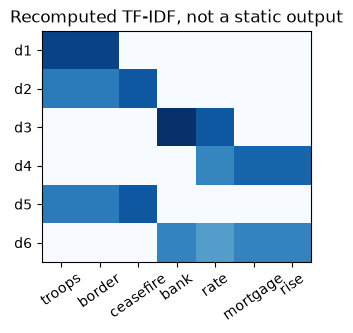

In [4]:
df = np.sum(counts > 0, axis=0)
idf = np.log((len(docs)+1)/(df+1)) + 1
tf = np.where(counts > 0, 1+np.log(np.maximum(counts,1)), 0)
weighted_terms = tf * idf
tfidf = weighted_terms / np.linalg.norm(weighted_terms, axis=1, keepdims=True)
assert_close(np.linalg.norm(tfidf,axis=1), 1)
print('df:',df,'\nidf:',idf,'\nTF-IDF:',tfidf)
record_result('idf_troops',idf[0]);record_result('idf_ceasefire',idf[2])
fig, ax = plt.subplots(figsize=(8,3)); ax.imshow(tfidf,cmap='Blues'); ax.set_xticks(range(7),terms,rotation=35); ax.set_yticks(range(6),['d1','d2','d3','d4','d5','d6']); ax.set_title('Recomputed TF-IDF, not a static output');plt.show()

## Cosine similarity

Let $a$ and $b$ be two nonzero rows with the same vocabulary order, and $a_t,b_t$ their entries for term $t$. The summation sign $\sum_t$ means add over every vocabulary term. Their *dot product*, $a\cdot b$, multiplies corresponding entries and adds them. Write $\lVert a\rVert=\sqrt{\sum_t a_t^2}$ for the norm, with the radical denoting a square root. Cosine similarity, written $\cos(a,b)$, is their dot product divided by their two lengths:

$$\cos(a, b) = \frac{a \cdot b}{\lVert a\rVert  \, \lVert b\rVert } = \sum_t a_t b_t \quad \text{when } \lVert a\rVert  = \lVert b\rVert  = 1.$$

A cosine of 1 means the same direction, 0 means perpendicular directions, and $-1$ means opposite directions. The zero row has no defined cosine. Single bars around a scalar, as in $|-2|=2$, mean absolute value: size without sign. Double bars denote a vector norm. The symbol $\approx$ means approximately equal.

In Figure 1, d2 and d5 share *troops, border, ceasefire* in the same proportions and have cosine 1.0; d1 and d3 share nothing and have cosine 0. Cosine is the similarity used throughout Eigen Times—for clustering a day's articles into stories, for threading stories into episodes, for finding precedents—so §8 is largely about what values of it mean.

### Laboratory: Compute document similarity and guard zero vectors

The symmetric `similarities` table contains every pairwise cosine. Because the
TF-IDF rows have unit norm, a matrix product computes them all. The d2/d5 match is
one and the d1/d3 match is zero; the assertions use indices starting at zero in
code. A zero-vector cosine remains undefined, rather than silently becoming a
match.

In [5]:
similarities = tfidf @ tfidf.T
assert_close(similarities[1,4],1);assert_close(similarities[0,2],0)
print(similarities)
record_result('cosine_d2_d5',similarities[1,4])
try: cosine(np.zeros(2), np.ones(2))
except ValueError: print('Correctly rejected the zero-vector cosine.')
else: raise AssertionError('zero direction accepted')

[[1.       0.766634 0.       0.       0.766634 0.      ]
 [0.766634 1.       0.       0.       1.       0.      ]
 [0.       0.       1.       0.330675 0.       0.679207]
 [0.       0.       0.330675 1.       0.       0.854787]
 [0.766634 1.       0.       0.       1.       0.      ]
 [0.       0.       0.679207 0.854787 0.       1.      ]]
cosine_d2_d5 = 1
Correctly rejected the zero-vector cosine.


## Embeddings

A TF‑IDF vector knows only which words appear. Two headlines using no shared retained terms have perpendicular, or *orthogonal*, TF‑IDF rows even if their meanings agree. A *sentence embedding* is a vector produced by a trained neural network—a numerical model that learns from examples—in which cosine similarity can track meaning beyond vocabulary. Eigen Times uses `bge-small-en-v1.5`, trained on hundreds of millions of sentence pairs, to turn a headline and lede (opening text: the first 300 characters, at most 96 tokens, or model text units) into 384 numbers. We treat the network as a black box that gives us a vector; everything downstream is linear algebra. These embedding vectors are dense and *not centred*: their mean has not been subtracted. News embeddings share a large common component, so the observed cosine between unrelated articles is around 0.5, not 0. That fact drives two of the thresholds in §8 and §9.

### Laboratory: A common component can inflate raw similarity

This **synthetic geometry** does not run or reproduce the neural embedding model.
Let `common` be a shared component; the remaining two coordinates identify
different topics. We compare raw vectors and the vectors after subtracting the
known common component. The result demonstrates a mechanism, not a re-estimate
of the archive's reported cosine distribution.

In [6]:
common=np.array([1.,0.,0.]);a=np.array([1.,1.,0.]);b=np.array([1.,0.,1.])
record_result('shared_component_raw_cosine',cosine(a,b))
record_result('shared_component_centered_cosine',cosine(a-common,b-common))
assert_close(cosine(a,b),.5);assert_close(cosine(a-common,b-common),0)

shared_component_raw_cosine = 0.5
shared_component_centered_cosine = 0


# Matrices, pictured

## A matrix times a vector

Let $n$ count document rows and $p$ count their coordinates. Stacking them gives an $n\times p$ matrix $X$: the shape always lists rows before columns. Individual observation vectors will be written as columns when used in projection or outer-product formulas; their transposes supply the rows of a data matrix. A transpose exchanges rows and columns and is marked $\top$. Thus a column $x$ has row form $x^{\top}$.

For Figure 2, let $A$ be a $4\times3$ example matrix and $v$ a $3\times1$ column of weights, with entries $v_1$ through $v_3$. Their product $Av$ is a $4\times1$ column. Adjacent mathematical symbols mean multiplication when their shapes permit it.

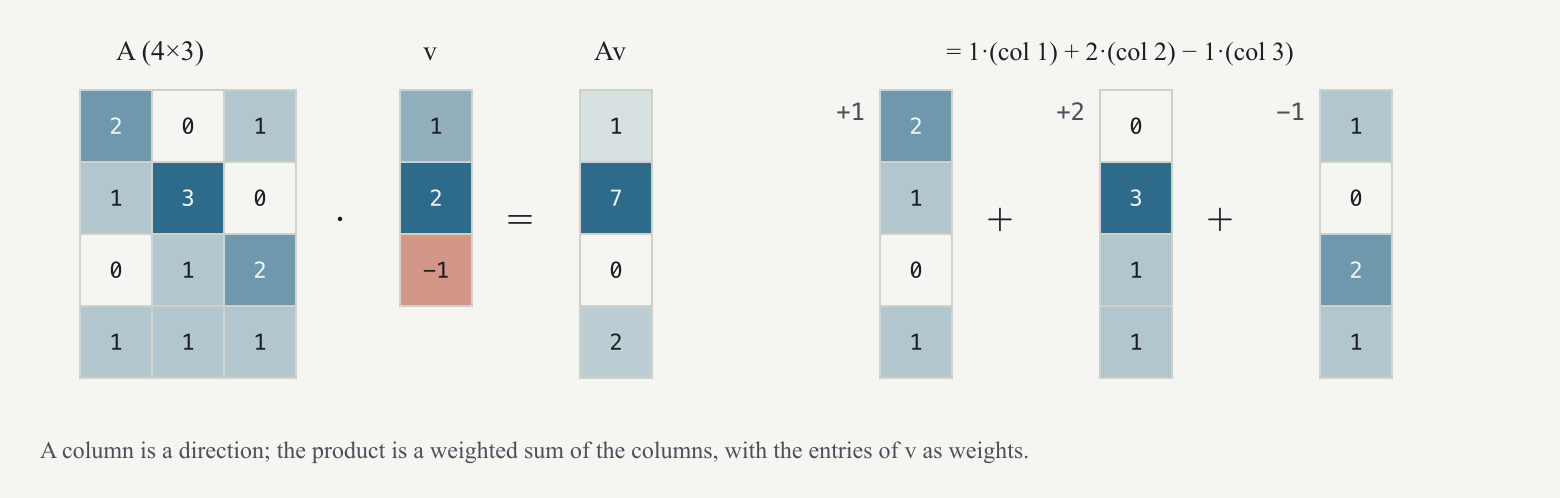

*A matrix times a vector is a weighted sum of the matrix's columns.*

The definition of $Av$ is "dot each row of $A$ with $v$", but the picture to keep is the other one (Figure 2): $Av$ is a *weighted sum of the columns of $A$*, with the entries of $v$ as the weights. If the columns of $A$ are directions, $Av$ is the point you reach by going $v_1$ of the way along the first, $v_2$ along the second, and so on. That is what "coordinates" will mean in §7: the coordinates of a story are the weights that best rebuild it from the basis directions.

### Laboratory: Rebuild Figure 2

`a_mv` and `v_mv` are the exact Figure 2 inputs. `product` computes row dot
products; `column_sum` computes the weighted column sum. These two descriptions
must agree entry by entry.

In [7]:
a_mv=np.array([[2,0,1],[1,3,0],[0,1,2],[1,1,1]],float);v_mv=np.array([1,2,-1.])
product=a_mv@v_mv;column_sum=sum(v_mv[j]*a_mv[:,j] for j in range(3))
assert_close(product,column_sum);assert_close(product,[1,7,0,2])
print('A v =',product);record_result('matvec_second',product[1])

A v = [1. 7. 0. 2.]
matvec_second = 7


## A matrix times a matrix

For Figure 3, take a new $3\times4$ example $A$, let $B$ be $4\times2$, and call their product $C=AB$. Indices $i$ and $j$ select a row and column: entry $C_{ij}$ is the dot product of row $i$ of $A$ with column $j$ of $B$. Shapes must agree in the middle: $(3\times4)(4\times2)$ gives $3\times2$. Two special cases recur. $X^{\top}X$ is the $p\times p$ matrix of dot products between columns of $X$, the raw material of covariance. Let $k$ count selected, mutually perpendicular unit directions and let $V$ contain them as $p\times1$ columns. Then $XV$ has shape $n\times k$: every document's coordinates on those directions, or the archive *projected* onto them.

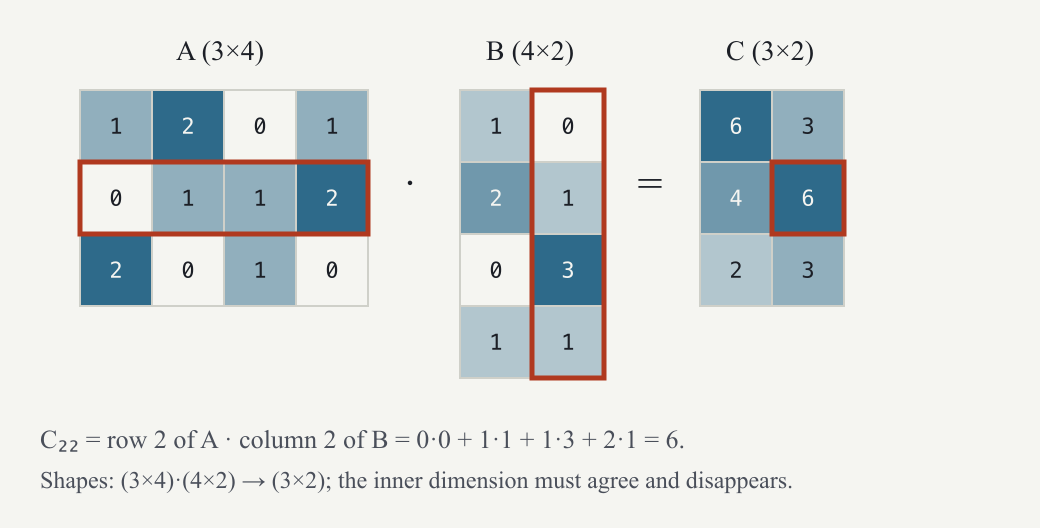

*Matrix multiplication: each entry of the product is a row of the left factor dotted with a column of the right one.*

### Laboratory: Rebuild Figure 3 and check shapes

`a_mm` is 3 by 4 and `b_mm` is 4 by 2. The product's second row, second
column is the manuscript's worked value six. A transpose exchanges row and
column roles without changing any entries.

In [8]:
a_mm=np.array([[1,2,0,1],[0,1,1,2],[2,0,1,0]],float)
b_mm=np.array([[1,0],[2,1],[0,3],[1,1]],float)
product_mm=a_mm@b_mm
assert product_mm.shape==(3,2);assert_close(product_mm[1,1],6)
print(product_mm);record_result('matrix_product_22',product_mm[1,1])

[[6. 3.]
 [4. 6.]
 [2. 3.]]
matrix_product_22 = 6


## Transpose, symmetry, orthogonality

$A^{\top}$ flips rows and columns. A *square* matrix has the same number of rows and columns. Call such a matrix $S$; it is *symmetric* when $S=S^{\top}$. Real symmetric matrices, including covariances, admit a complete set of real, mutually perpendicular eigenvector directions, defined in the next chapter.

Unit-length perpendicular columns are *orthonormal*. The identity matrix $I$ has ones on its diagonal and zeros elsewhere; multiplying by it changes nothing. A $p\times k$ matrix $V$ with orthonormal columns satisfies $V^{\top}V=I$, here with a $k\times k$ identity. If $k=p$, the matrix is *orthogonal*: multiplication by $V$ or $V^{\top}$ rotates or reflects coordinates and preserves all lengths and angles. If $k<p$, the map $V^{\top}x$ keeps only a projection; it can shorten $x$ and change angles between observations. Its reconstruction $VV^{\top}x$ retains only the selected subspace. Directions are *independent* when none is a weighted combination of the others; a *basis* is a set of independent directions used to express a space, and *rank* counts a matrix's independent directions.

### Laboratory: A projection is not a full rotation

`basis` retains two axes in three-dimensional space. It has orthonormal columns,
but its projection drops the third coordinate. `rotation` is square and
orthogonal, so it preserves lengths. We explicitly check the distinction that
motivated the companion's notation correction.

In [9]:
basis=np.eye(3)[:,:2];observation=np.array([1.,2.,3.])
assert_close(basis.T@basis,np.eye(2))
assert_close(np.linalg.norm(basis.T@observation)**2,5)
assert_close(np.linalg.norm(observation)**2,14)
rotation=np.array([[0.,-1.],[1.,0.]])
assert_close(np.linalg.norm(rotation@observation[:2]),np.linalg.norm(observation[:2]))
record_result('discarded_projection_energy',14-5)

discarded_projection_energy = 9


# The covariance and its eigenvectors

## Centering and covariance

Let $i$ index fitted articles, from 1 to $n$, and let $d$ count embedding coordinates. Each $x_i$ is a $d\times1$ column; row $i$ of the $n\times d$ data matrix $X$ is $x_i^{\top}$. Let $w_i$ be its nonnegative fit weight. The first edition uses uniform article weights; the later archive fit uses inverse daily article counts, explained in §11. These weights are distinct from the story energy used to rank news. Let $Z>0$ be total weight, $\mu$ the $d\times1$ weighted mean, and $\Sigma$ the $d\times d$ weighted covariance. A sum over $i$ includes every fitted article, and $Z^{-1}$ means $1/Z$:

$$Z = \sum_i w_i, \qquad \mu = Z^{-1} \sum_i w_i x_i,$$

$$\Sigma = Z^{-1} \sum_i w_i (x_i - \mu)(x_i - \mu)^{\top}.$$

Subtracting the mean is *centering*. A column multiplied by its transpose is an *outer product*: a $d\times d$ table of all pairwise coordinate products. In Figure 4, coordinates indexed by $j$ and $l$ occupy entry $(j,l)$. Its weighted average is their covariance: positive when their centred values tend to move together, negative when oppositely. A diagonal entry is a *variance*, the average squared deviation from a mean. Its nonnegative square root is a *standard deviation*. These formulas use total-weight normalization, not an unbiased sample correction. In Eigen Times $d=384$, so $\Sigma$ is a $384\times384$ matrix—147,456 numbers summarising the fitted article cloud.

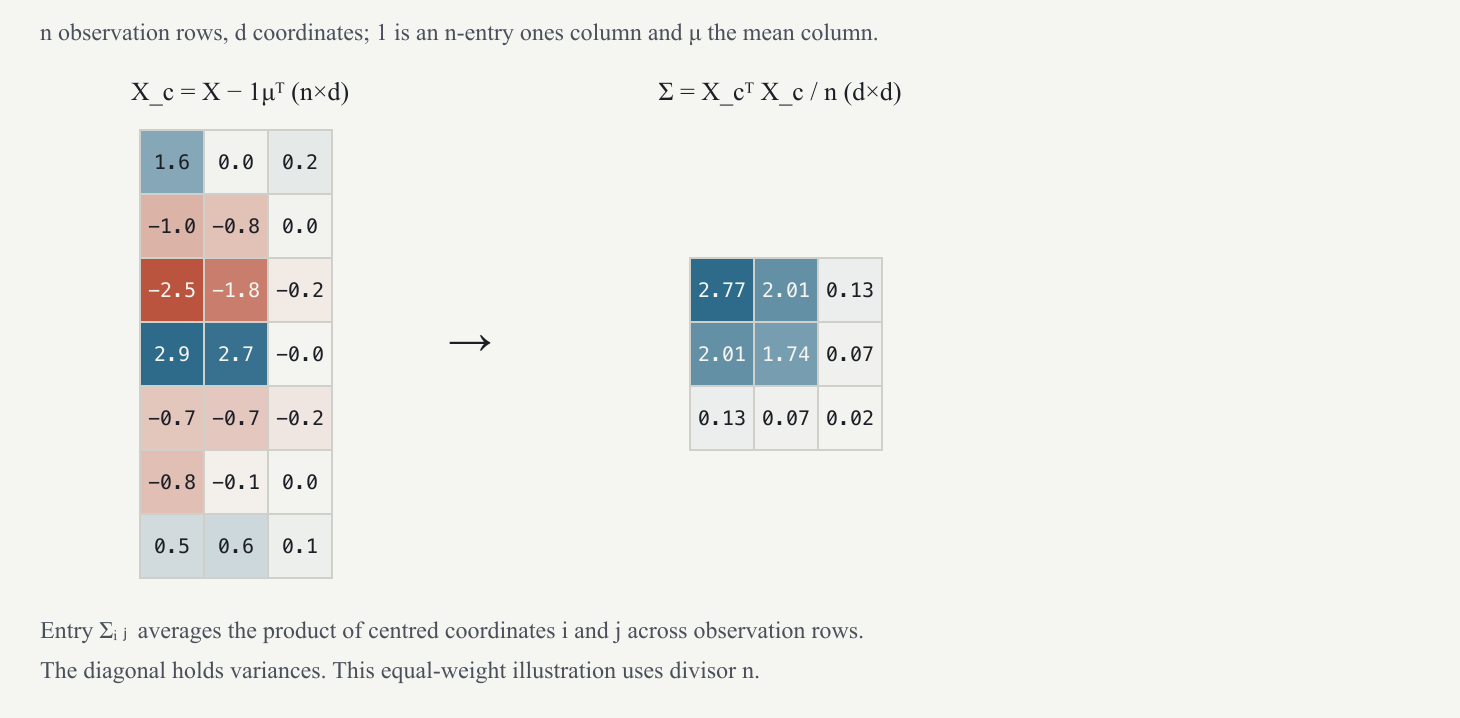

*The covariance matrix: centre the rows, then average the outer products.*

A practical point matters for updates. Let $m$ be the $d\times1$ weighted coordinate sum and $M$ the $d\times d$ weighted outer-product sum:

$$m=\sum_i w_i x_i,\qquad M=\sum_i w_i x_i x_i^{\top}.$$

Then $\mu=m/Z$ and $\Sigma=M/Z-\mu\mu^{\top}$. These three running sums retain everything needed for these mean and covariance calculations. New observations with fixed weights can be added without revisiting old observations. If a day's final article count changes its existing weights, the old contributions must also be corrected. Let $W=\mathrm{diag}(w_1,\ldots,w_n)$ be the $n\times n$ diagonal weight matrix: $\mathrm{diag}$ puts the listed values on the diagonal and zeros elsewhere. Let $\mathbf1$ be a column of $n$ ones. The centred data matrix is $X_c=X-\mathbf1\mu^{\top}$, and equivalently $\Sigma=X_c^{\top}WX_c/Z$.

### Laboratory: Compute Figure 4 and a weighted covariance two ways

`covariance_rows` embeds the seven raw numeric rows generated by Figure 4's seed
3 recipe; freezing these inputs lets both languages compute the same example
without pretending their random generators are identical. `weights` are an
editable synthetic unequal-weight fixture. `mu` is the weighted mean and `cov`
the total-weight-normalized covariance. `moment_cov` reconstructs it from the
three sufficient sums. No sample-size correction is applied here.

In [10]:
figure_cov=covariance_rows.T@covariance_rows/len(covariance_rows)
weights=np.array([1,2,1,3,1,2,1.]);mu,cov=covariance(covariance_rows,weights)
z=weights.sum();m=weights@covariance_rows
second=covariance_rows.T@(weights[:,None]*covariance_rows)
moment_cov=second/z-np.outer(m/z,m/z)
assert_close(cov,moment_cov);assert_close(cov,cov.T)
print('Figure 4 covariance:',figure_cov,'\nweighted mean:',mu,'\nweighted covariance:',cov)
record_result('figure_covariance_trace',np.trace(figure_cov));record_result('weighted_covariance_trace',np.trace(cov))

Figure 4 covariance: [[2.774325 2.009925 0.127041]
 [2.009925 1.744141 0.066284]
 [0.127041 0.066284 0.019534]] 
weighted mean: [0.357983 0.418601 0.003987] 
weighted covariance: [[3.305474 2.642168 0.070266]
 [2.642168 2.351654 0.034031]
 [0.070266 0.034031 0.01259 ]]
figure_covariance_trace = 4.53799937191
weighted_covariance_trace = 5.66971811229


## Eigenvectors: the axes of the cloud

A cloud of points in $d$ dimensions has a shape. The eigenvectors of its covariance are the axes of that shape—the directions along which the points spread most, then next most, and so on, each perpendicular to the last—and the eigenvalues are the variances along those axes. Figure 5 shows 300 points in two dimensions: the long axis has eigenvalue 4.06, the short one 0.44, so about 90% of the displayed variation lies along one direction. The synthetic distribution has known mean zero. This illustration forms second moments about that origin, rather than subtracting the finite sample's empirical mean; the displayed eigenvalues estimate population variances.

Formally, a nonzero $d\times1$ column $v$ is an *eigenvector* of $\Sigma$ with *eigenvalue* $\lambda$ when $\Sigma v=\lambda v$: multiplication scales it without turning it. A covariance has nonnegative eigenvalues. Choose $d$ unit, mutually perpendicular eigenvectors $v_j$, ordered by decreasing eigenvalue $\lambda_j$, with $j=1,\ldots,d$. Let $V$ contain those columns and $\Lambda$ the diagonal matrix of their eigenvalues, both $d\times d$. They diagonalise the covariance, meaning

$$\Sigma = V\Lambda V^{\top},\qquad V^{\top}V=I,\qquad \Lambda=\mathrm{diag}(\lambda_1,\ldots,\lambda_d),$$

where $\lambda_1\ge\lambda_2\ge\cdots\ge\lambda_d\ge0$ and $\ge$ means greater than or equal to. The diagonal representation has zero covariances between different eigenvector coordinates. The *principal components* are these directions, ranked by variance; using them to summarize the cloud is principal component analysis (PCA).

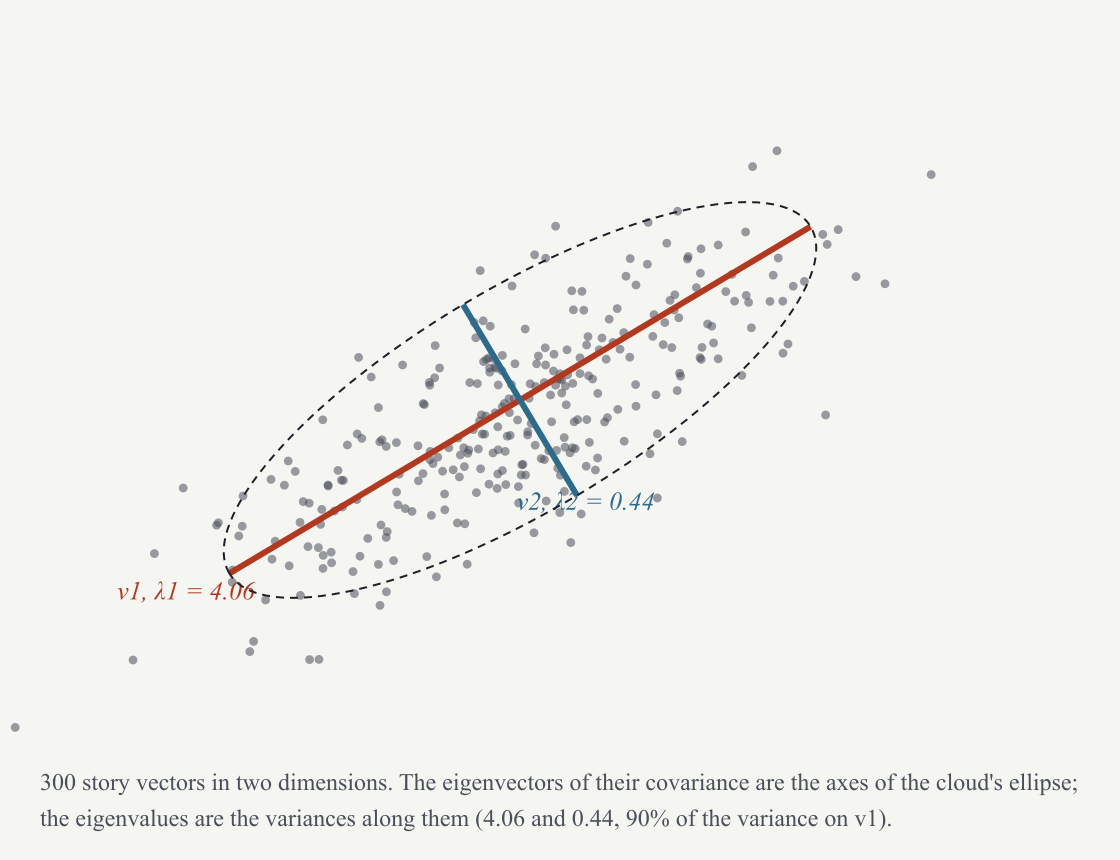

*Eigenvectors describe the point cloud's axes. This synthetic illustration estimates variances about the known population mean zero.*

For any $d\times1$ unit direction $u$, the projected variance is $u^{\top}\Sigma u$. The direction that maximises it is $v_1$, with value $\lambda_1$; the best direction perpendicular to $v_1$ is $v_2$; and so on. This is the content of "the eigen‑news are the directions that explain the most variance". Computing them for a $384\times384$ symmetric matrix is a standard numerical operation (`eigh` in common linear-algebra libraries; `faer` in the Rust implementation) and takes milliseconds in the reported fit.

### Laboratory: Recompute the 300-point illustration

`cloud_points` contains the exact synthetic Figure 5 input rows. The manuscript
uses their second moment about the **known population mean zero**. We reproduce
that choice rather than silently replacing it with empirical centering. `lam`
contains descending eigenvalues and `eigenvectors` their unit column directions.
We verify the eigen-equation and full reconstruction, and then compare the
slightly different empirically centered covariance.

About known zero: [4.055288 0.437844] ; centered finite-sample eigenvalues: [4.033375 0.418543]
cloud_lambda_1 = 4.05528795494
cloud_lambda_2 = 0.437844202539
cloud_variance_fraction = 0.902552565295


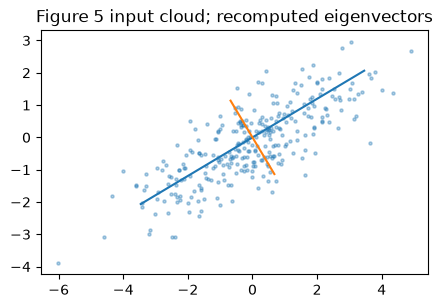

In [11]:
cloud_second=cloud_points.T@cloud_points/len(cloud_points)
lam,eigenvectors=np.linalg.eigh(cloud_second);lam=lam[::-1];eigenvectors=eigenvectors[:,::-1]
assert_close(cloud_second@eigenvectors,eigenvectors*lam)
assert_close(eigenvectors@np.diag(lam)@eigenvectors.T,cloud_second)
assert_close(np.round(lam,3),FIXTURES['expected']['eigen2d'],tol=1e-7)
_,centered_cloud=covariance(cloud_points,np.ones(len(cloud_points)))
print('About known zero:',lam,'; centered finite-sample eigenvalues:',np.linalg.eigvalsh(centered_cloud)[::-1])
record_result('cloud_lambda_1',lam[0]);record_result('cloud_lambda_2',lam[1]);record_result('cloud_variance_fraction',lam[0]/lam.sum())
fig,ax=plt.subplots(figsize=(5,4));ax.scatter(*cloud_points.T,s=5,alpha=.35)
for j in range(2):
    axis=2*np.sqrt(lam[j])*eigenvectors[:,j];ax.plot([-axis[0],axis[0]],[-axis[1],axis[1]])
ax.set_aspect('equal');ax.set_title('Figure 5 input cloud; recomputed eigenvectors');plt.show()

## How many axes to keep

Let $k\le d$ count retained directions; $\le$ means less than or equal to. The *explained-variance fraction* is $\sum_{j=1}^{k}\lambda_j/\sum_{j=1}^{d}\lambda_j$, provided total variance is positive. It reports how much of the fitted cloud's variation those directions retain. For the Eigen Times embedding basis, 60 components carry 55% of the variance, and the curve is flat beyond; a small eigenvalue alone does not prove that a direction is meaningless.

The *Marchenko–Pastur edge* is a noise-model reference. In this illustration, let $N$ count independent observations in $d$ coordinates with equal noise variance $\sigma^2$, unrelated to the singular-value notation used later. Let $\lambda_+$ denote the approximate upper edge of the noise covariance spectrum. Under that model, in the large-sample limit,

$$\lambda_{+} = \sigma^2 \left(1 + (d/N)^{1/2}\right)^2,$$

Here raising to $1/2$ means taking a square root. Eigenvalues near or below that reference may be noise; this is not a universal significance test for correlated, weighted news data. The median eigenvalue supplies a rough noise-variance estimate in this comparison. With $N\approx10^6$ and $d=384$, the ratio $d/N$ is tiny and the edge is close to that estimate. The deployed bases use fixed $k=60$, with the variance curve as a check. From here onward $V$ usually means only the retained $d\times k$ columns and $\Lambda$ their $k\times k$ positive eigenvalue matrix; full decompositions will be identified explicitly.

### Laboratory: Variance retention and a noise-model reference

`noise_variance` is an illustrative assumed noise variance, not a fit to news.
`edge` is the Marchenko–Pastur reference for one million independent observations
and 384 coordinates. It is close to that variance because the dimension/count
ratio is small. We also evaluate the exact two-dimensional variance curve. The
book's 60-axis/55% archive result remains a dated observation, not something a
300-point toy fixture can reproduce.

In [12]:
noise_variance=.01;sample_count=1_000_000;dimensions=384
edge=noise_variance*(1+np.sqrt(dimensions/sample_count))**2
print('Noise reference:',edge,'; retained fractions:',np.cumsum(lam)/lam.sum())
record_result('mp_edge',edge)

Noise reference: 0.010395758358845306 ; retained fractions: [0.902553 1.      ]
mp_edge = 0.0103957583588


# The singular value decomposition and LSA

## What the SVD is

The eigendecomposition works on a square covariance. The *singular value decomposition* (SVD) works on a rectangular data matrix. For this section let $X$ be any $n\times d$ matrix. Let $U$ be an $n\times n$ orthogonal matrix of left directions, and $V$ a $d\times d$ orthogonal matrix of right directions. Let $\Sigma_{\mathrm{svd}}$ be an $n\times d$ rectangular diagonal matrix: its only potentially nonzero entries lie where row and column indices agree. Those entries are nonnegative *singular values*, or scale factors, written $\sigma_j$ in decreasing order. Then

$$X=U\Sigma_{\mathrm{svd}}V^{\top}.$$

Figure 6 labels this singular-value matrix with the traditional bare $\Sigma$; it is a different object from the covariance $\Sigma$ in §4. The columns of $V$ are directions indexed by features, and those of $U$ are directions indexed by observations. Actual coordinate scores are $XV=U\Sigma_{\mathrm{svd}}$, not $U$ alone: each left direction must receive its singular-value scale.

Let $q=\min(n,d)$, where $\min$ selects the smaller number. The *thin* SVD removes the unused full-matrix directions: it has $U$ of shape $n\times q$, $\Sigma_{\mathrm{svd}}$ of shape $q\times q$, and $V$ of shape $d\times q$, with the same product $X$. Keeping only $k<q$ directions is the further operation of *truncation*.

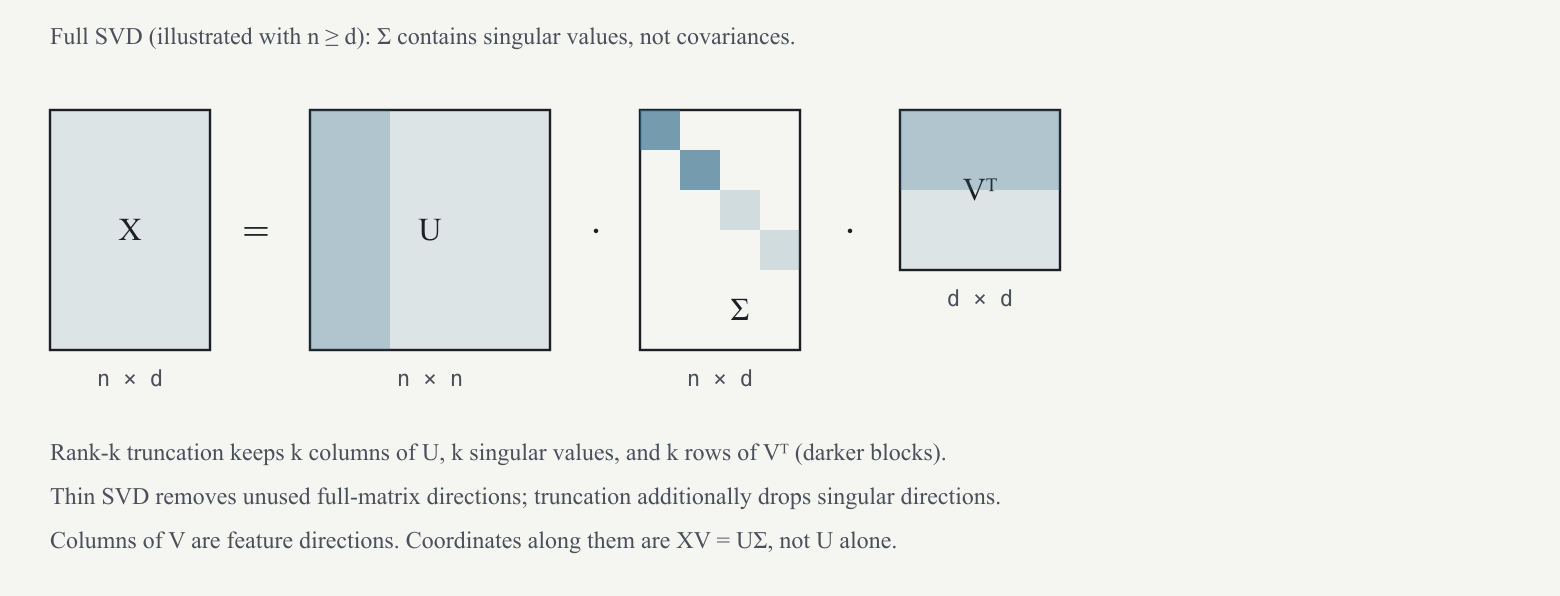

*The SVD as blocks. The darker parts illustrate a rank-k truncation: k columns of U, k singular values, and k rows of the transpose of V. The figure's Sigma denotes the singular-value matrix.*

For the full rectangular decomposition, $X^{\top}X=V(\Sigma_{\mathrm{svd}}^{\top}\Sigma_{\mathrm{svd}})V^{\top}$. For the thin one, the middle product is the square diagonal matrix $\Sigma_{\mathrm{svd}}^2$. If $X$ is centred and equally weighted, the covariance with divisor $n$ therefore has the same right directions and $\lambda_j=\sigma_j^2/n$. For the weighted covariance of §4, instead decompose $W^{1/2}X_c$, where the diagonal entries of $W^{1/2}$ are $\sqrt{w_i}$; then divide squared singular values by total weight $Z$. Scores for the original, unweighted observations are still $X_cV$. A direction's *canon* is its representative collection of high-scoring stories; a left singular vector alone is not generally the original article-score column in a weighted fit.

### Laboratory: Thin factors, scores and covariance eigenvalues

`u_svd`, `singular`, and `v_svd` are thin SVD factors of the six-document
matrix, with the right directions stored as **columns**, not transposed rows.
OCaml computes them natively from a Jacobi eigendecomposition of the small Gram
matrix. Squaring a matrix condition number makes this a teaching technique for
small fixtures, not a production SVD recommendation. Singular values whose squares fall below a scale-relative roundoff threshold
are treated as numerical zero; their left directions are completed orthonormally. We verify
reconstruction, scaled scores, and the centered covariance identity.

In [13]:
u_svd,singular,vt_svd=np.linalg.svd(tfidf,full_matrices=False);v_svd=vt_svd.T
assert_close((u_svd*singular)@v_svd.T,tfidf)
assert_close(tfidf@v_svd,u_svd*singular)
centered_t=tfidf-tfidf.mean(0)
_,center_singular,_=np.linalg.svd(centered_t,full_matrices=False)
center_lam=np.linalg.eigvalsh(centered_t.T@centered_t/len(tfidf))[::-1]
assert_close(center_lam[:len(center_singular)],center_singular**2/len(tfidf))
print('singular values:',singular,'; thin shapes:',u_svd.shape,singular.shape,v_svd.shape)
record_result('singular_1',singular[0]);record_result('singular_2',singular[1])

singular values: [1.641318 1.505547 0.824434 0.553241 0.231598 0.      ] ; thin shapes: (6, 6) (6,) (7, 6)
singular_1 = 1.64131778803
singular_2 = 1.50554693072


## Truncation

Let $U_k$ and $V_k$ contain the first $k$ columns of the thin factors, and let $\Sigma_k$ contain their $k$ singular values on its diagonal. Their shapes are $n\times k$, $d\times k$, and $k\times k$, respectively. The approximation $X_k=U_k\Sigma_kV_k^{\top}$ has rank at most $k$. *Least squares* means minimizing the sum of squared entry-by-entry errors. The *Frobenius norm*, written $\lVert A\rVert_F$ for any matrix $A$, is the square root of the sum of its squared entries. The Eckart–Young theorem says this truncation minimizes $\lVert X-X_k\rVert_F$ among matrices of rank at most $k$.

Figure 7 applies this to the six-document matrix of Figure 1. Its singular values are 1.64, 1.51, 0.82, 0.55, and then almost nothing. Relative error means $\lVert X-X_k\rVert_F/\lVert X\rVert_F$ for nonzero $X$. Rank 1 rebuilds only the war documents (relative error 0.74); rank 2 rebuilds both blocks, war and banking, and the error drops to 0.42; rank 3 reaches 0.24. Two components already separate the two kinds of document in this small example.

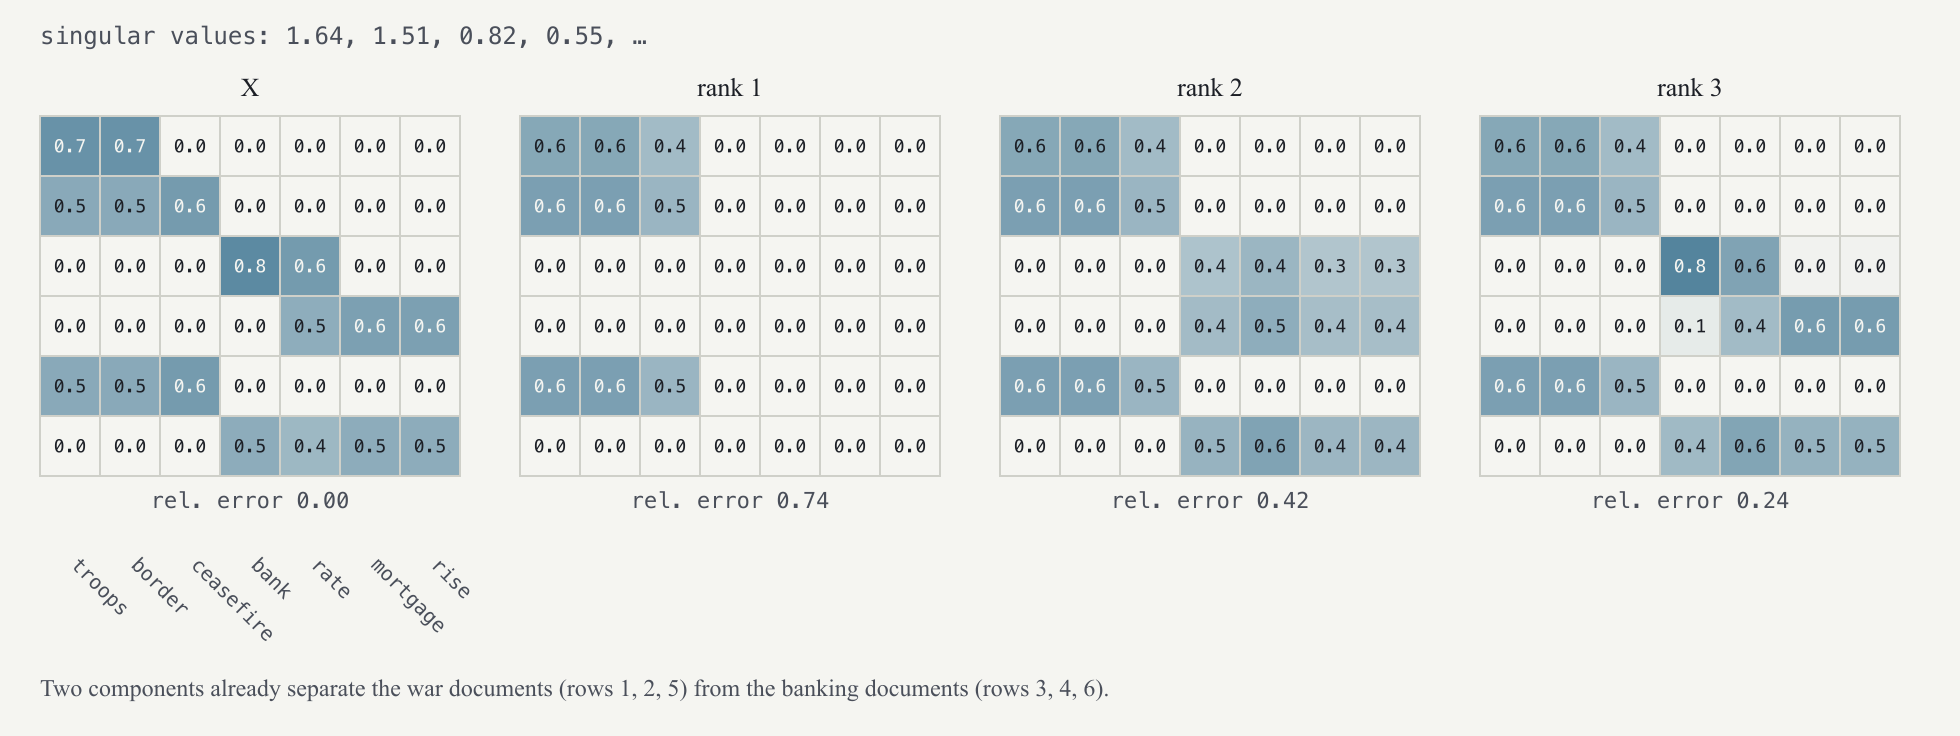

*Truncated SVD of the toy corpus. Rank 1 captures one block; rank 2 captures both.*

### Laboratory: Recompute every low-rank error in Figure 7

For retained rank `k`, `reconstruction` keeps the first `k` scaled singular
directions. The relative Frobenius error can also be computed from discarded
squared singular values. These are the exact six-document worked examples;
rounded values agree with the manuscript and `example-numbers.json`.

In [14]:
for k in [1,2,3]:
    reconstruction=(u_svd[:,:k]*singular[:k])@v_svd[:,:k].T
    error=np.linalg.norm(tfidf-reconstruction)/np.linalg.norm(tfidf)
    assert_close(error,np.sqrt(np.sum(singular[k:]**2)/np.sum(singular**2)))
    record_result(f'rank_{k}_relative_error',error)
assert_close(round(RESULTS['rank_2_relative_error'],3),FIXTURES['expected']['rank2_error'])

rank_1_relative_error = 0.742302265331
rank_2_relative_error = 0.416213959022
rank_3_relative_error = 0.244851562117


## Latent semantic analysis

*Latent semantic analysis* (LSA) uses a truncated SVD of a document–term matrix such as TF‑IDF; Eigen Times additionally centres and, in the archive edition, weights that matrix. Each retained column of $V$ is a direction over terms. Its entries are *loadings*: coefficients telling how strongly each input feature contributes to the direction. Its largest term loadings provide a word list (Figure 8). In the toy corpus the first component loads on *troops, border, ceasefire*, the second on *bank, rate, mortgage, rise*. In the real Eigen Times v0 basis the axes read *bank · financial · credit · rate · loan*, *Russian · Russia · Ukraine · Putin · Moscow*, *flight · airline · passenger · airport · crash*, and so on—sixty word lists that a reader recognises at once.

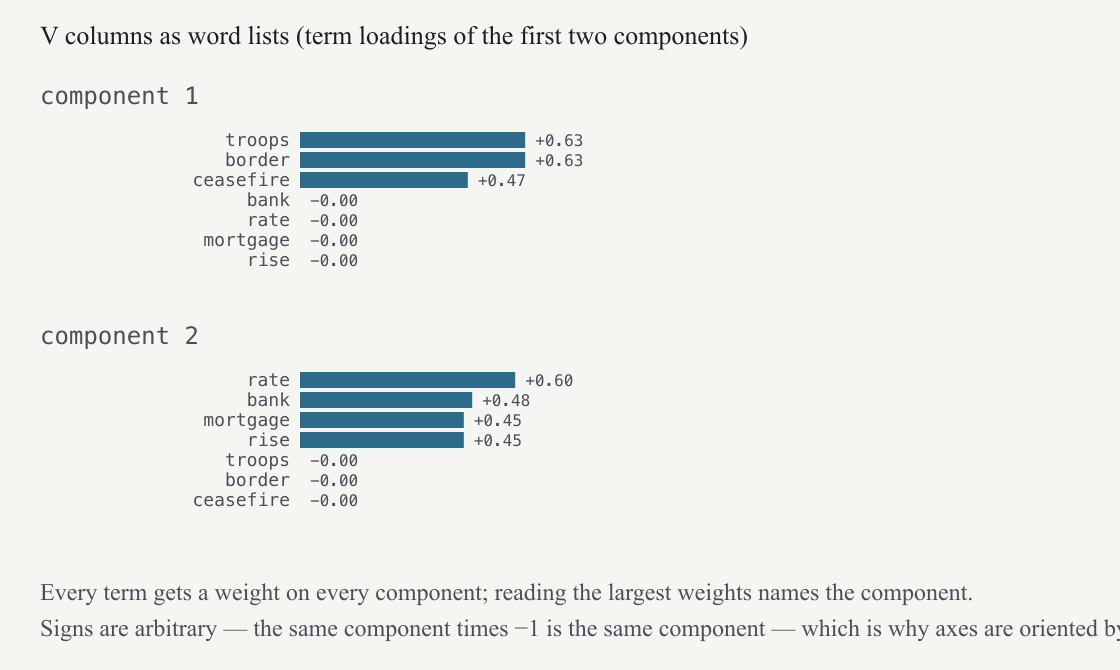

*Term loadings: each column of $V$ is a weighted word list.*

Two details of the real computation deserve explanation.

*Implicit centering.* For this calculation, $X$ has $n$ document rows and $p$ term columns, $\mu$ is its $p\times1$ reference mean, and $\mathbf1$ has $n$ entries. Forming $X_c=X-\mathbf1\mu^{\top}$ would fill its zeros and destroy sparsity. Let $l$ count a small number of working columns, let $\Omega$ be any $p\times l$ matrix, and let $Y$ be $n\times l$. The algorithm needs only products with the centred matrix, which expand as

$$X_c\Omega=X\Omega-\mathbf1(\mu^{\top}\Omega),$$
$$X_c^{\top}Y=X^{\top}Y-\mu(\mathbf1^{\top}Y).$$

The results have shapes $n\times l$ and $p\times l$. Each correction is an outer product, of rank at most one. The sparse $X$ is used as is; the centred dense matrix need never be stored.

*Randomized SVD.* A $1{,}093{,}166\times50{,}000$ matrix is far too large for a full classical SVD here, but only the top 60 directions are wanted. The method of Halko, Martinsson and Tropp approximates them with repeated matrix products. Draw a random $50{,}000\times80$ matrix $\Omega$: $l=80$ working columns provide $k=60$ desired directions plus 20 extra directions for approximation. Form $Y=X_c\Omega$, then *orthonormalise* its columns: replace them with perpendicular unit directions spanning the same space. Random combinations can capture the leading directions well when the singular values decay sufficiently.

Two rounds of *power iteration* amplify stronger singular directions relative to weaker ones. The update $Y\leftarrow X_c(X_c^{\top}Y)$ means replace $Y$ by that product, orthonormalising between rounds; it does not form a huge $X_cX_c^{\top}$ matrix. Call the final $n\times l$ orthonormal working matrix $Q_{\mathrm{range}}$. Decompose the smaller $l\times p$ matrix $Q_{\mathrm{range}}^{\top}X_c$, then map its left directions back with $Q_{\mathrm{range}}$. This gives an approximate truncated SVD of $X_c$. Weighted fitting applies the same method to $W^{1/2}X_c$. Each sparse product touches the nonzero entries once. On the reported laptop the first LSA fit, including tokenising 1.6 GB of text twice, takes about five minutes. A fixed random seed, input order, and numerical procedure make the computation reproducible.

### Laboratory: Word lists, implicit centering and randomized range finding

`omega` is a fixed editable working matrix, so both languages use identical
inputs instead of incompatible random streams. `forward` and `backward` apply
the centered operator without constructing its dense subtraction. We check both
identities. Then two power rounds and orthonormalization form `q_range`; an SVD
of the compressed matrix gives an approximate rank-two reconstruction. The
sketch has four working columns here, rather than the archive's 80. The displayed
word lists are recomputed from the toy right directions, with signs irrelevant
to the sorted absolute loading strengths.

In [15]:
for j in range(2):
    print('axis',j+1,[(terms[i],round(abs(v_svd[i,j]),4)) for i in np.argsort(-abs(v_svd[:,j]))[:4]])
term_mean=tfidf.mean(0)
omega=np.array([[np.sin((i+1)*(j+2)) for j in range(4)] for i in range(7)])
forward=lambda o:tfidf@o-np.ones((6,1))@(term_mean@o)[None,:]
backward=lambda y:tfidf.T@y-term_mean[:,None]@y.sum(0)[None,:]
assert_close(forward(omega),centered_t@omega)
assert_close(backward(forward(omega)),centered_t.T@(centered_t@omega))
q_range=np.linalg.qr(forward(omega),mode='reduced')[0]
for _ in range(2):q_range=np.linalg.qr(forward(backward(q_range)),mode='reduced')[0]
small=q_range.T@centered_t
small_u,small_s,small_vt=np.linalg.svd(small,full_matrices=False)
random_reconstruction=(q_range@small_u[:,:2]*small_s[:2])@small_vt[:2]
random_error=np.linalg.norm(centered_t-random_reconstruction)/np.linalg.norm(centered_t)
optimal_error=np.sqrt(np.sum(center_singular[2:]**2)/np.sum(center_singular**2))
assert random_error>=optimal_error-1e-9 and random_error<optimal_error+.02
record_result('randomized_rank2_error',random_error)

axis 1 [('troops', np.float64(0.6256)), ('border', np.float64(0.6256)), ('ceasefire', np.float64(0.466)), ('bank', np.float64(0.0))]
axis 2 [('rate', np.float64(0.5979)), ('bank', np.float64(0.4781)), ('mortgage', np.float64(0.455)), ('rise', np.float64(0.455))]
randomized_rank2_error = 0.32407112998


# From eigenvectors to named axes

## Two ambiguities

Eigenvectors come with two kinds of freedom that the mathematics does not fix and a newspaper must.

*Sign.* If $v$ is an eigenvector, so is $-v$: the same axis pointing the other way. Flipping both the direction and its scores changes no reconstruction; its positive and negative *poles* exchange names. Eigen Times fixes orientation using *skewness*, asymmetry in the score distribution. A *central moment* averages powers of deviations from the mean. Let $m_2$ and $m_3$ denote the second and third central moments on one axis. When $m_2>0$, skewness is $m_3/m_2^{3/2}$, and its sign is the sign of $m_3$. Flip the axis if $m_3<0$, so its longer tail points positive. A zero third moment supplies no preferred sign. The streaming chapter computes these moments from article scores without retaining every score.

*Rotation inside the subspace.* Equal eigenvalues are called *degenerate*: any perpendicular unit pair in their plane is an eigenbasis. Close eigenvalues can make individual directions sensitive to small data changes, even when their shared subspace is stable (Figure 9). A *perturbation* is such a change to the covariance; the *eigenvalue gap* is the separation from neighbouring eigenvalues. The tracking chapter explains the bound relating them. Even distinct principal axes can be difficult to name: variance-maximising directions may blend subjects such as markets and party politics. Naming keeps the selected subspace and chooses different axes inside it; the rotated axes need no longer be covariance eigenvectors.

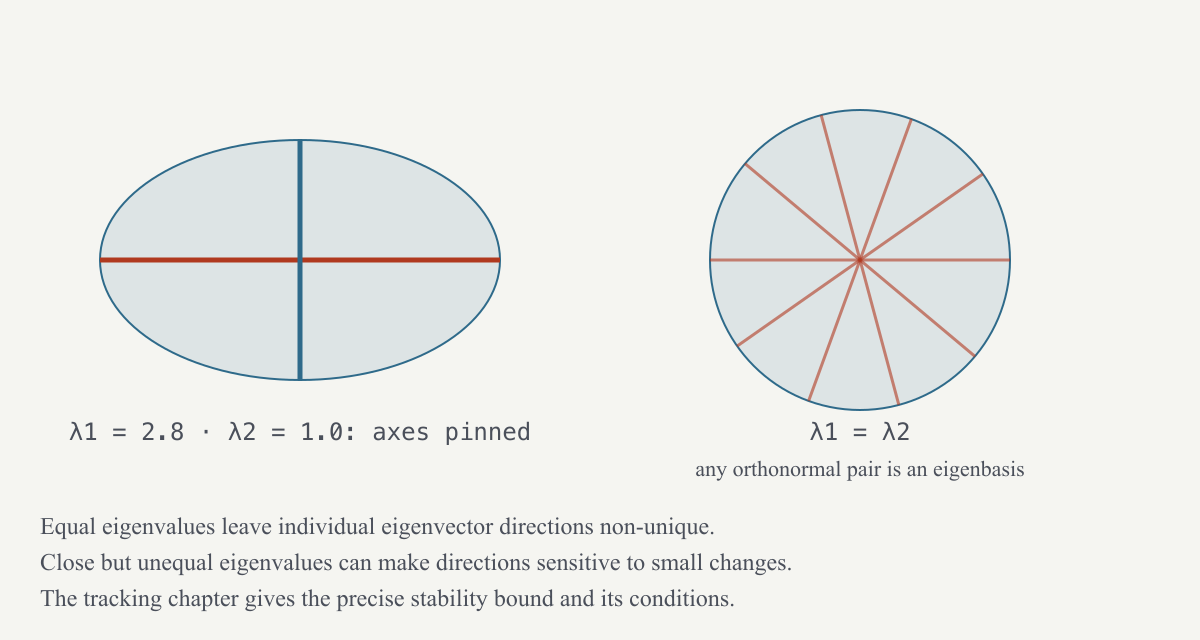

*Well‑separated eigenvalues pin the axes; exactly equal ones admit many eigenbases, while nearly equal ones are sensitive to perturbations. The tracking chapter gives the precise stability bound.*

### Laboratory: Skewness orientation and degeneracy

`signed_scores` are an editable one-axis fixture with a long negative tail.
`m2` and `m3` are its second and third central moments. Reversing the sign
reverses `m3`. A separate repeated-eigenvalue covariance remains unchanged by
rotation, demonstrating why individual eigenvectors are not identifiable inside
that plane.

In [16]:
signed_scores=np.array([-5.,-1.,0.,1.,1.]);centered_scores=signed_scores-signed_scores.mean()
m2=np.mean(centered_scores**2);m3=np.mean(centered_scores**3)
orientation=-1 if m3<0 else 1
assert np.mean((orientation*centered_scores)**3)>0
angle=np.pi/5;rotation2=np.array([[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]])
assert_close(rotation2.T@(2*np.eye(2))@rotation2,2*np.eye(2))
record_result('orientation_third_moment',m3)
print('skewness:',m3/m2**1.5,'; orientation sign:',orientation)

orientation_third_moment = -12.384
skewness: -1.1210847078122883 ; orientation sign: -1


## Varimax

Recall the retained $d\times k$ orthonormal basis $V$. Let $R$ be a $k\times k$ orthogonal rotation and let $V'=VR$ be the named basis; the prime means rotated. If $c$ is a $k\times1$ raw coordinate column, its named column is $y=R^{\top}c$ (also sometimes written $c'$). Both bases reconstruct the same projection because $VRy=Vc$. Residual length is unchanged. The covariance-adjusted distance called $T^2$ in §7 is also unchanged *when its covariance is transformed consistently*; it is not determined by the subspace alone.

Kaiser's *varimax* criterion selects a rotation making each direction load strongly on a few features and weakly on the rest. Let $p$ count those features, let $i=1,\ldots,p$ index them, and let $j=1,\ldots,k$ index axes. Write $\ell_{ij}$ for row $i$, column $j$ of the rotated loading table. The criterion maximises the following sum of within-column variances of squared loadings:

$$\sum_{j=1}^{k}\left[\frac1p\sum_{i=1}^{p}\ell_{ij}^{4}-\left(\frac1p\sum_{i=1}^{p}\ell_{ij}^{2}\right)^2\right].$$

The fourth power appears because it is the square of a squared loading. Figure 10 shows six variables in two groups mixed by 30°. Their small secondary loadings make the computed maximizing rotation approximately $-33.3°$, rather than an exact reversal of the mixing angle. The rotation concentrates each variable on one axis without making its other loading exactly zero.

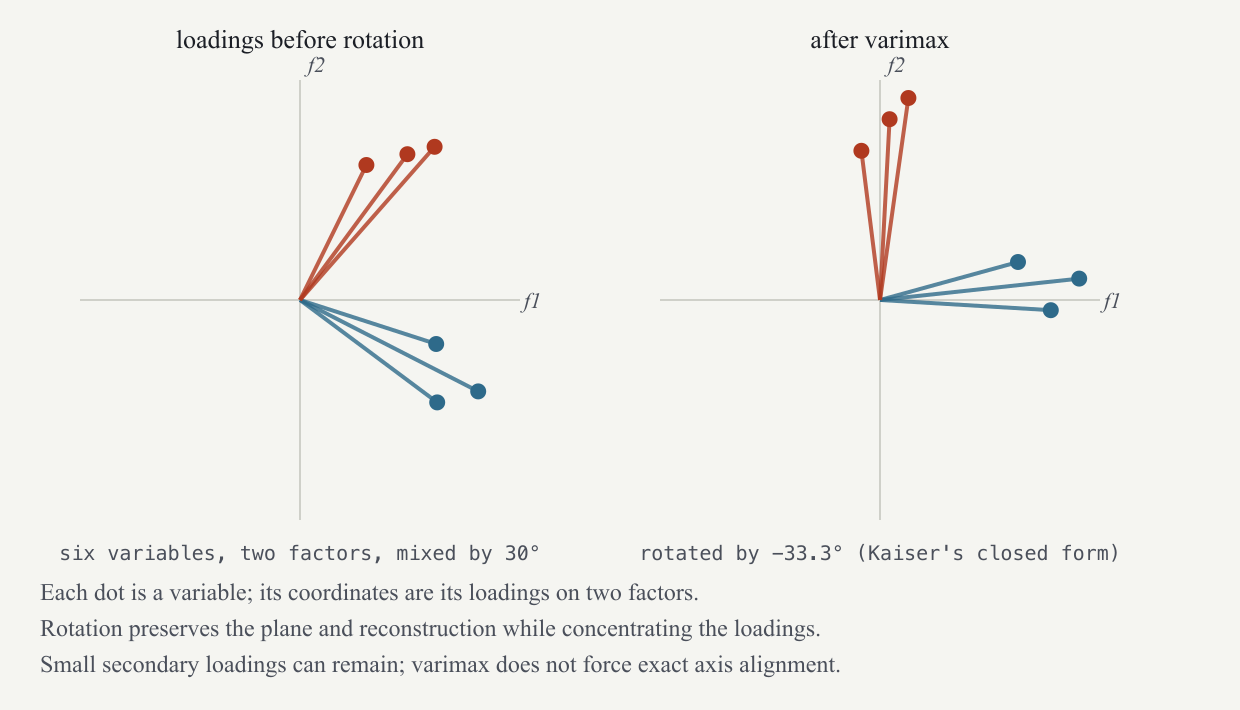

*Varimax: the same plane, different axes. Before rotation the loadings are mixed; afterwards they are more concentrated on individual factors, with small secondary loadings remaining.*

Eigen Times sweeps over every pair of axes, rotating just that pair by its best angle. This two-coordinate operation is a *Givens rotation*. For one pair only, let $x,y$ be its $p\times1$ loading columns, distinct from article and score vectors elsewhere. *Elementwise* arithmetic treats each row separately: define $u_i=x_i^2-y_i^2$ and $v_i=2x_i y_i$. Define the four scalar sums $A=\sum_i u_i$, $B=\sum_i v_i$, $C=\sum_i(u_i^2-v_i^2)$, and $D=\sum_i2u_i v_i$. These local capital letters are scalars, not earlier matrices. The function $\operatorname{atan2}(a,b)$ returns the angle of the two-dimensional point with horizontal coordinate $b$ and vertical coordinate $a$, preserving its quadrant. Let $\phi$ be the chosen rotation angle in radians:

$$\phi = \tfrac{1}{4}\,\operatorname{atan2}\left(D - 2AB/p,\; C - (A^2 - B^2)/p\right).$$

One full turn is $2\pi$ radians, where $\pi$ is the circle constant. A *sweep* visits every axis pair. Sweeps stop when no pair rotates by more than $10^{-6}$ radians (one millionth of a radian), or after fifty sweeps. If both arguments of $\operatorname{atan2}$ are zero, the pair supplies no preferred rotation. Exact pairwise maximization cannot decrease the criterion, so its bounded objective improves monotonically; that does not guarantee the global best orientation. The reported alternative, an SVD-based fixed-point iteration (repeatedly applying one update rule), oscillated between two mirror-image states on a symmetric configuration, motivating the pairwise method.

For the embedding basis, naming rotates associations with words rather than unexplained embedding coordinates. Let $T$ be the $N\times p$ article TF‑IDF matrix, $\mu_T$ its $p\times1$ article mean, and $\mathbf1$ a column of $N$ ones. Let $S$ be an $N\times k$ table of raw eigen-coordinates divided by their positive raw-axis standard deviations. This is *whitening* in the unrotated eigenbasis: coordinates have unit reference variance and zero reference cross-covariance. Let $\beta$ be the $p\times k$ term-loading matrix:

$$\beta=\left(T-\mathbf1\mu_T^{\top}\right)^{\top}S.$$

Here $p=50{,}000$ and $k=60$. Lexical whitening floors its raw variance denominators at $10^{-12}$ before taking square roots. The embedding naming fit rotates $\beta$; the LSA fit rotates its right singular directions, already indexed by terms. Applying the resulting $R$ to the corresponding raw coordinate map gives named directions. Because scaling and rotation need not give the same result in opposite orders, word associations fitted from whitened scores are labels for investigation, not exact term-by-term decompositions of every stored named score. The block-sum chapter expands the centred loading formula. The older shorthand $T^{\top}U$ assumes compatible centred, scaled score columns; the SVD factor $U$ must not generally be substituted for $S$.

### Laboratory: Recompute the exact pairwise Givens angle and lexical loadings

`clean_loadings` is the six-variable fixture from Figure 10. `mixed_loadings`
rotates it by 30 degrees. The four scalar sums give the closed-form improving
angle `phi`. We recompute the objective before and after, obtaining approximately
−33.28 degrees. `whitened_scores` are raw principal coordinates divided by their
positive standard deviations; `beta` is their centered association with terms.
The final equality checks the expanded cross-product formula.

In [17]:
clean_loadings=np.array([[1,.05],[.85,-.1],[.7,.15],[.1,.9],[-.05,.75],[.2,1.]])
def rotation_matrix(angle):return np.array([[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]])
mixed_loadings=clean_loadings@rotation_matrix(np.pi/6)
def pair_angle(matrix,j,l):
    x,y=matrix[:,j],matrix[:,l];u=x*x-y*y;v=2*x*y;p=len(x)
    aa,bb,cc,dd=u.sum(),v.sum(),(u*u-v*v).sum(),(2*u*v).sum()
    return np.arctan2(dd-2*aa*bb/p,cc-(aa*aa-bb*bb)/p)/4
objective=lambda a:np.sum(np.mean(a**4,axis=0)-np.mean(a*a,axis=0)**2)
phi=pair_angle(mixed_loadings,0,1);named_loadings=mixed_loadings@rotation_matrix(phi)
assert objective(named_loadings)>=objective(mixed_loadings)-1e-12
assert_close(np.linalg.norm(named_loadings),np.linalg.norm(mixed_loadings))
raw_values,raw_directions=np.linalg.eigh(centered_t.T@centered_t/len(tfidf))
raw_variances=raw_values[::-1][:2];raw_scores=centered_t@raw_directions[:,::-1][:,:2]
whitened_scores=raw_scores/np.sqrt(np.maximum(raw_variances,1e-12))
assert_close(whitened_scores.T@whitened_scores/len(tfidf),np.eye(2))
beta=centered_t.T@whitened_scores
assert_close(beta,tfidf.T@whitened_scores-np.outer(term_mean,whitened_scores.sum(0)))
record_result('varimax_angle_degrees',np.degrees(phi));record_result('varimax_objective_gain',objective(named_loadings)-objective(mixed_loadings))
assert_close(round(np.degrees(phi),2),FIXTURES['expected']['varimax_angle'])
print('Named loadings:',named_loadings,'\nterm associations:',beta)

varimax_angle_degrees = -33.278610189
varimax_objective_gain = 0.243533078283
Named loadings: [[ 0.995504  0.107109]
 [ 0.854328 -0.051224]
 [ 0.690276  0.189788]
 [ 0.048364  0.904246]
 [-0.092812  0.745913]
 [ 0.142481  1.009802]] 
term associations: [[-1.774013  0.069874]
 [-1.774013  0.069874]
 [-1.326175  0.062983]
 [ 1.254583 -1.314496]
 [ 1.566341 -0.335614]
 [ 1.182377  1.059844]
 [ 1.182377  1.059844]]


# Measuring a story

## Projection, reconstruction, residual

Let $x$ be one $d\times1$ article or representative story-vector column, $\mu$ its $d\times1$ fitted article mean, and $V$ the retained $d\times k$ raw basis with orthonormal columns. Let $c$ be its $k\times1$ coordinate column, $\hat x$ its $d\times1$ reconstruction (the hat means an approximation), and $r$ its $d\times1$ residual. They are measured in three lines (Figure 11):

$$c = V^{\top} (x - \mu), \qquad \hat{x} = \mu + V c, \qquad r = x - \hat{x}.$$

The coordinates are the weights giving the least-squares reconstruction of $x-\mu$ from the basis directions. Adding the mean gives $\hat x$. The residual $r$ is perpendicular to every retained direction. This *orthogonal projection* loses the component outside the selected subspace.

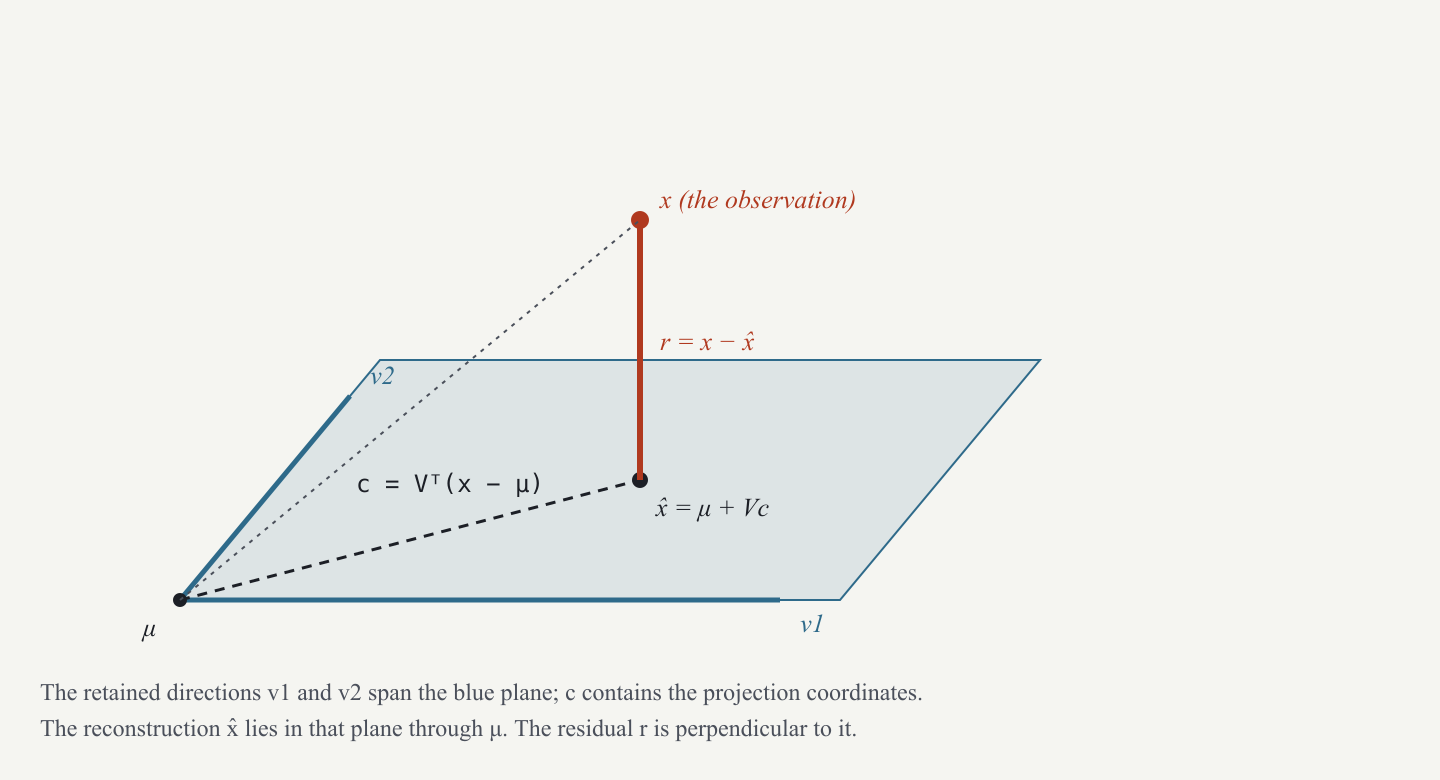

*A story against the basis: its projection onto the news subspace, and the residual perpendicular to it.*

### Laboratory: A fully computed story measurement

For this **synthetic observation**, `story=[2,1,3]`, the mean is zero and the
retained basis consists of the first two coordinate directions. `coords`,
`reconstructed`, and `residual` implement the three displayed equations. The
Pythagorean check verifies that retained and residual squared lengths add to the
total centered squared length.

In [18]:
story=np.array([2.,1.,3.]);reference_mean=np.zeros(3);measurement_basis=np.eye(3)[:,:2]
coords=measurement_basis.T@(story-reference_mean)
reconstructed=reference_mean+measurement_basis@coords;residual=story-reconstructed
assert_close(measurement_basis.T@residual,0)
assert_close(coords@coords+residual@residual,(story-reference_mean)@(story-reference_mean))
print('coordinates:',coords,'reconstruction:',reconstructed,'residual:',residual)
record_result('projection_q',residual@residual)

coordinates: [2. 1.] reconstruction: [2. 1. 0.] residual: [0. 0. 3.]
projection_q = 9


## T² and Q

Define two scalar statistics: $T^2$, Hotelling's squared covariance-adjusted distance within the retained space, and $Q$, the residual squared length. Here $T^2$ is the statistic's name, not the square of the TF‑IDF matrix $T$. Recall that $\Lambda$ contains the $k$ retained positive raw eigenvalues $\lambda_j$, and $c_j$ is coordinate $j$ of the raw column $c$. A superscript $-1$ means matrix inverse; for diagonal $\Lambda$, it replaces each positive eigenvalue by its reciprocal. Sum over $j=1,\ldots,k$:

$$T^{2} = c^{\top} \Lambda^{-1}c = \sum_j \frac{c_j^2}{\lambda_j}, \qquad Q = \lVert r\rVert ^{2}.$$

$Q$ measures the component outside the retained subspace; it can include discarded familiar variation as well as new material. $T^2$ is the squared length after whitening the raw coordinates: divide each $c_j$ by the reference standard deviation $\sqrt{\lambda_j}$. A *z-score* is a value minus its reference mean, divided by its positive reference standard deviation; these raw coordinates already have reference mean zero. Figure 12 shows why division matters: equal Euclidean distances can have different covariance-adjusted distances. With 60 fitted positive directions, the fitted average of $T^2$ under the matching covariance weights is 60; a value of 400 is much larger. Those magnitudes alone do not supply a calibrated probability or universal alarm threshold.

The calculation uses raw eigen-coordinates before the naming rotation. In named coordinates $y=R^{\top}c$, let $\Gamma=R^{\top}\Lambda R$ be their $k\times k$ covariance. The same statistic is $T^2=y^{\top}\Gamma^{-1}y$. In general $\Gamma$ is not diagonal: simply dividing rotated coordinates by the old $\lambda_j$, or even by their own marginal variances, does not reproduce this statistic. Marginal standardization gives each coordinate unit variance separately; full whitening also removes cross-covariances. The implementation sums $c_j^2/\lambda_j$ only for positive raw eigenvalues and contributes zero otherwise. The inverse formulas here assume positive retained eigenvalues.

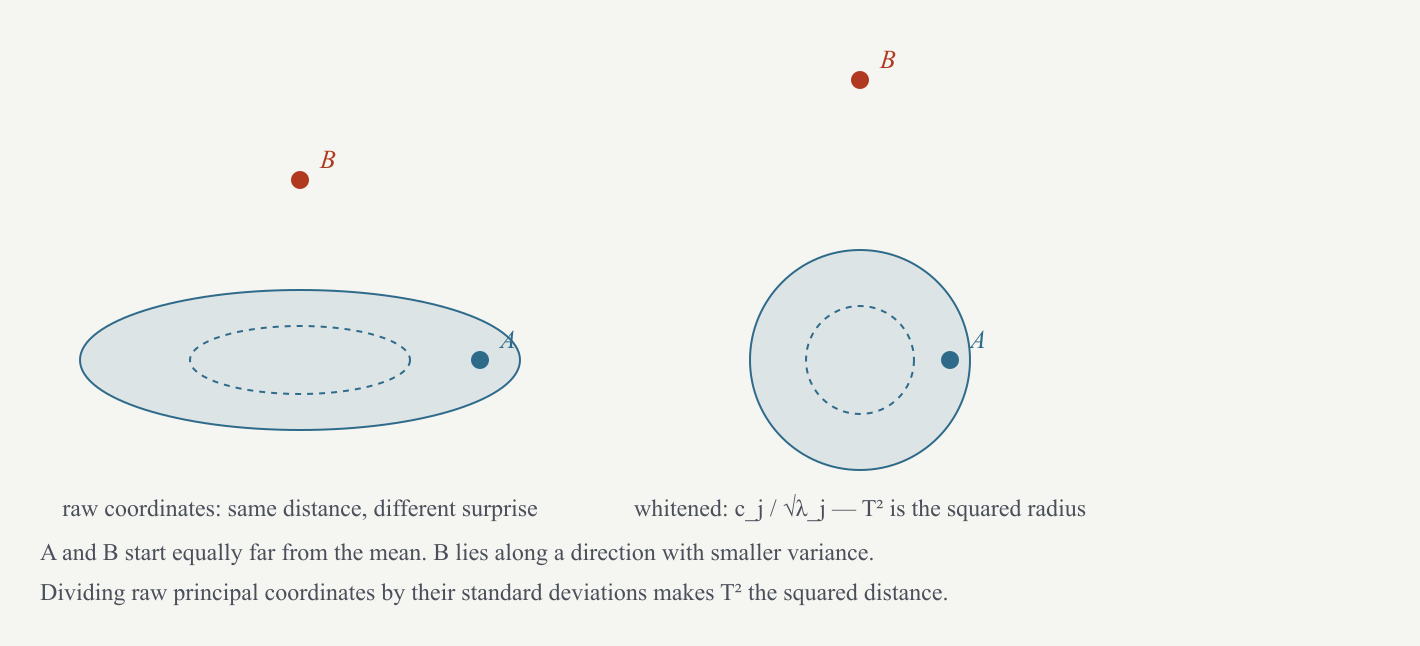

*Whitening: after dividing each raw eigen-coordinate by its axis's standard deviation, squared distance from the centre is T squared.*

The two statistics come from monitoring variation against a principal-component reference model. A high $T^2$ means a large covariance-adjusted displacement within retained directions; a high $Q$ means a large component outside them. Neither proves that an event is unprecedented.

Let $\nu$ (Greek nu) denote the *novelty ratio*. When $x$ differs from $\mu$, written $x\ne\mu$, define $\nu=Q/\lVert x-\mu\rVert^2$: residual squared length divided by total centred squared length. Orthogonality keeps it between 0 and 1. Zero means fully represented in the retained subspace; one means the centred vector is perpendicular to that subspace. At $x=\mu$, both numerator and denominator are zero; the implementation returns zero as a software convention for this undefined ratio. This geometric use of "energy" means squared length, not the attention score defined below.

These equations describe one vector. The site's stored story statistics are means of its member articles' $T^2$, $Q$, and $\nu$ values. They need not equal the statistics calculated from a story's mean embedding: averaging and a squared distance or ratio generally give different results in opposite orders.

### Laboratory: Whitening, rotation invariance and means that do not commute

`reference_variances=[4,1]` are stipulated positive variances of the two raw
axes. `t2` is the squared covariance-adjusted distance, `q` is residual energy,
and `novelty` is its share of total energy. `gamma` is the covariance after a
30-degree rotation. The full inverse reproduces `t2`; dividing by rotated
marginal variances generally does not. Finally two opposite member vectors have
a nonzero mean individual distance, despite their centroid being zero.

In [19]:
reference_variances=np.array([4.,1.]);t2=np.sum(coords**2/reference_variances);q=residual@residual
novelty=q/((story-reference_mean)@(story-reference_mean));rotation_measure=rotation_matrix(np.pi/6)
named_coords=rotation_measure.T@coords;gamma=rotation_measure.T@np.diag(reference_variances)@rotation_measure
rotated_t2=named_coords@np.linalg.solve(gamma,named_coords)
naive_t2=np.sum(named_coords**2/np.diag(gamma))
assert_close(t2,rotated_t2);assert abs(naive_t2-t2)>.01
members=np.array([[2.,0.],[-2.,0.]])
mean_stat=np.mean(np.sum(members**2/reference_variances,axis=1))
centroid_stat=np.sum(members.mean(0)**2/reference_variances)
assert mean_stat>centroid_stat
def novelty_with_zero_convention(residual_energy,total_energy):
    return residual_energy/total_energy if total_energy>0 else 0.
assert novelty_with_zero_convention(0.,0.)==0.
record_result('hotelling_t2',t2);record_result('novelty_ratio',novelty);record_result('mean_member_t2',mean_stat)
print('Full rotated T²:',rotated_t2,'marginal-only shortcut:',naive_t2,'centroid T²:',centroid_stat)
assert_close(np.sum(raw_variances*(1/raw_variances)),2) # matching positive reference axes

hotelling_t2 = 2
novelty_ratio = 0.642857142857
mean_member_t2 = 1
Full rotated T²: 1.9999999999999996 marginal-only shortcut: 1.5431953914104055 centroid T²: 0.0


## Dominant axis, spectrum, profile

For a story $s$, let $y_s$ be its $k\times1$ named-coordinate column. Let $s_j>0$ be the empirical standard deviation of named coordinate $j$ across stories in the site's profile window: the latest ten years of loaded data. This scale is estimated separately from the raw eigenvalue $\lambda_j$; the implementation floors it at $10^{-6}$. The *dominant* archetype is the index maximizing the signed score $y_{sj}/s_j$. The operator $\arg\max_j$ returns that winning index, not its score. This rule uses neither absolute values nor subtraction of the empirical axis mean; it selects the largest score even when every score is negative.

One possible "mixed" heuristic is that, for positive top score $a_1$ and runner-up $a_2$, $(a_1-a_2)/a_1\le0.20$. The 20% denominator is the top score. This is an illustrative rule retained from the original explanation; it is not implemented by the current site.

Let $\varepsilon_s$ denote story energy: its number of distinct sources multiplied by $\ln(1+\text{article count})$. This measures attention, separately from article fit weights or vector squared lengths. A day's *spectrum* is the sum of its named story coordinates weighted by $\varepsilon_s$, divided by that day's positive total story energy. The *era statistics* are each spectrum coordinate's mean and standard deviation over all loaded day spectra. Welford's algorithm updates a count, mean, and squared-deviation accumulator without retaining every value. These are all-loaded-data comparisons, not historical forecasts restricted to days preceding a selected date. Each spectrum z-score subtracts its era mean and divides by its positive era standard deviation; the front page highlights values beyond $\pm2$ (plus or minus two) and lists values below $-2$ under *Silence*.

An archetype's *profile* records the mean and standard deviation of each named coordinate over the stories it dominates in the profile window. *Same as always* combines strong positive profile and story signals with agreement within one profile standard deviation; agreement alone is insufficient. *Different this time* lists departures exceeding 1.5 profile standard deviations. In this usage $\sigma$ is shorthand for a reference standard deviation, not an SVD singular value. A zero reference deviation cannot be used as a z-score denominator without an explicit fallback.

### Laboratory: Signed dominance, attention and the daily mixture

All numbers below are **editable teaching fixtures**. `named_rows` contains three
stories; `axis_sd` gives their reference named-axis standard deviations. The
winning index maximizes a signed standardized value, even if all are negative.
`attention` multiplies distinct sources by log(1+article count). `spectrum` is its
weighted average. The 20% mixed example is illustrative only, as the manuscript
explicitly states; it is not a deployed rule.

In [20]:
named_rows=np.array([[2.,1.],[-1.,-.1],[.5,3.]])
axis_sd=np.array([2.,.5]);standardized=named_rows/np.maximum(axis_sd,1e-6)
winners=np.argmax(standardized,axis=1)
assert winners[1]==1 # -0.2 exceeds -0.5; absolute-value ranking would differ
source_counts=np.array([2.,1.,3.]);article_counts=np.array([3.,1.,5.])
attention=source_counts*np.log1p(article_counts);spectrum=np.average(named_rows,axis=0,weights=attention)
mixed_scores=np.array([1.,.85]);illustrative_mixed=(mixed_scores[0]-mixed_scores[1])/mixed_scores[0]<=.2
assert illustrative_mixed
print('signed winners (zero-based):',winners,'attention:',attention,'spectrum:',spectrum)
record_result('spectrum_first',spectrum[0]);record_result('spectrum_second',spectrum[1])

signed winners (zero-based): [1 1 1] attention: [2.772589 0.693147 5.375278] spectrum: [0.852806 2.129745]
spectrum_first = 0.852805934136
spectrum_second = 2.12974536246


# The clustering thresholds

Every threshold in Eigen Times is a cosine, a z‑score, or a count, and every one of them was set by looking at a distribution. This chapter shows the distributions.

## Stories: single linkage on a day's articles

The articles of one day are grouped into stories by *single linkage*: two articles are linked if their cosine reaches a chosen threshold. The link graph has articles as nodes and those links as edges. A *connected component* contains articles joined by some chain of edges, even if the endpoints lack a direct link. A *union–find* structure efficiently keeps track of groups as links join them. Each component becomes a story. This has a familiar failure mode, *chaining* (Figure 13): intermediate similarities can connect unrelated endpoints. On a busy day, a slightly low threshold can let one chain swallow much of the news.

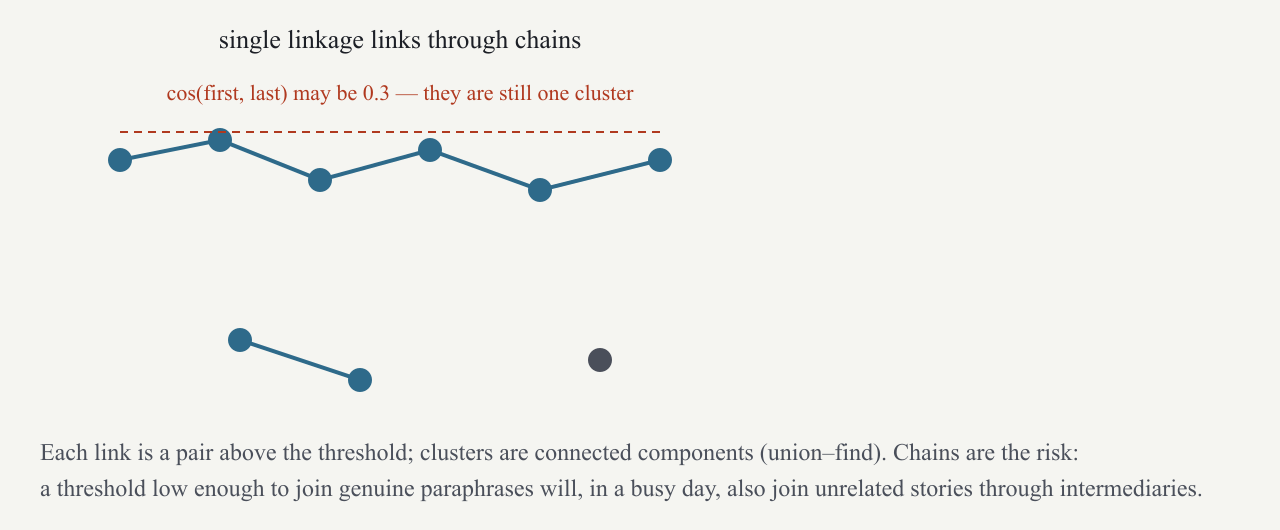

*Single linkage: clusters are connected components of the "similar enough" graph, so chains of intermediaries can join unrelated articles.*

Figure 14 is the evidence. It shows the cosine of every pair of articles on five busy days (12 September 2001, 16 September 2008, 24 June 2016, 12 March 2020, 24 February 2022), split by whether the two ended up in the same story. In embedding space, pairs from *different* stories have median cosine 0.49 and a 99th percentile of 0.67—confirming that unrelated news embeddings sit around 0.5, not 0—while pairs from the same story have median 0.65 and a long tail toward 1. The two distributions overlap, as they must for anything less than a perfect representation, but the crossover is narrow.

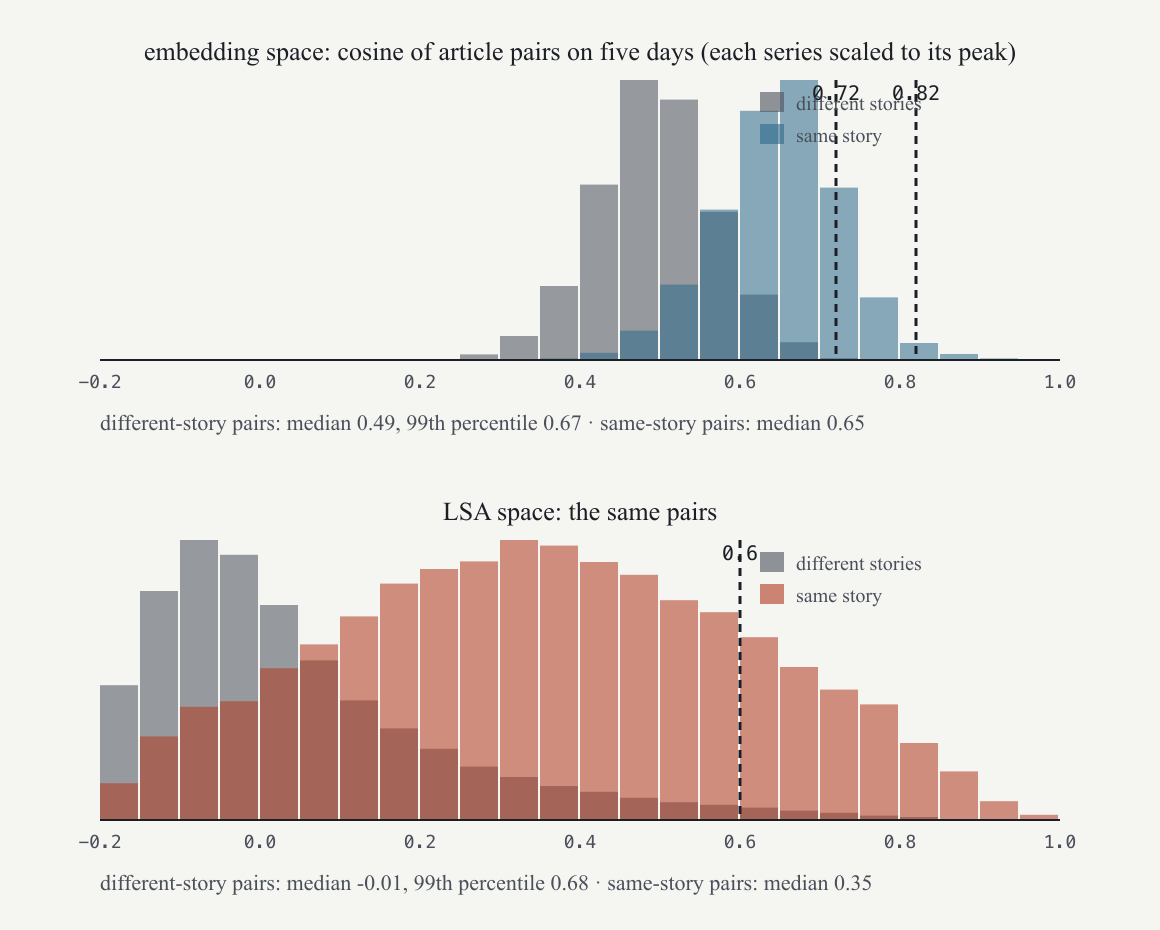

*Cosine similarity of article pairs on five busy days, in embedding space (top) and LSA space (bottom), split by whether the articles belong to the same story. Each series is scaled to its own peak.*

The threshold is where chaining stops and fragmentation has not yet started, and Figure 15 shows the search on 24 February 2022, the day Russia invaded Ukraine. At 0.6, one chain contains 143 of the day's 152 articles—the whole day is one "story". At 0.66 the chain still holds 104. At **0.72** the largest cluster is the 62‑article invasion story, which is what a human would want, with 67 singletons (features, comment, unrelated items). At 0.78 the invasion story has fragmented to 34 articles; at 0.82 no cluster is larger than 8; at 0.9 nothing is linked at all. The deployed threshold is 0.72. The original choice had been 0.82 (a number appropriate for a larger embedding model with longer inputs); the first look at the data—"Day of terror" on 12 September 2001 rendered as a three‑article story—showed it was wrong, and the sweep in Figure 15 replaced it.

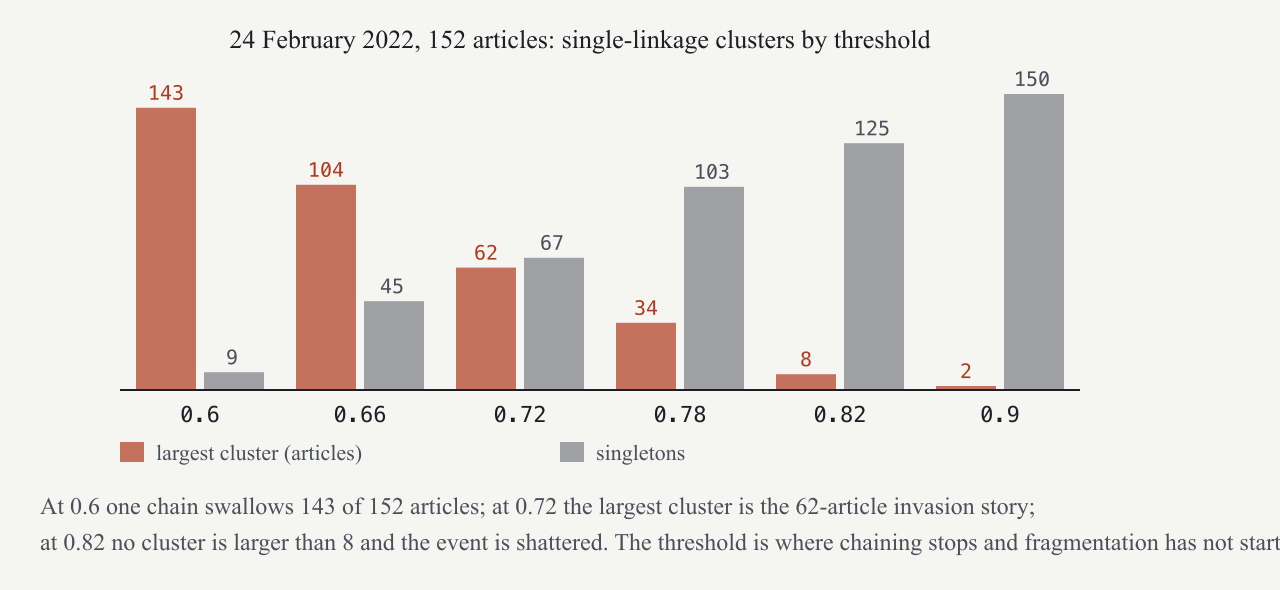

*Cluster sizes on 24 February 2022 as the threshold varies.*

The lower panel of Figure 14 explains why the LSA space needs a different threshold. LSA coordinates are projections onto the 60 leading right singular directions of the term matrix; articles about the same event share vocabulary but in a 60‑dimensional summary their cosines spread from 0 to 1 (median 0.35), and unrelated articles sit around 0 (median $-0.01$). The distributions are wider and cross lower, and the threshold that reproduces sensible stories is **0.6**. It is a diffuser space for this purpose—which is one of the reasons the deployed newspaper clusters in embedding space and uses the LSA basis only for measurement.

### Laboratory: Compute chaining and audit the archived threshold sweep

First we compute connected components on **synthetic unit vectors** at 0, 30,
60 and 90 degrees. A 0.72 link threshold connects the chain although its endpoint
cosine is zero; a 0.9 threshold separates all four. This illustrates the actual
algorithm without fabricating archive embeddings.

The second table recomputes proportions from the **frozen dated aggregate
fixture** `threshold-stats.json`; the underlying article vectors are not bundled,
so its historical clusters cannot be regenerated from scratch here. There is a
historical discrepancy: the prose says that 0.9 links nothing on 24 February
2022, while the archived fixture records 151 clusters, largest size 2, and 150
singletons among 152 articles. The executable table faithfully reports the
fixture, rather than repeating that sentence as an asserted result.

In [21]:
def components(vectors,threshold):
    parents=list(range(len(vectors)))
    def root(i):
        while parents[i]!=i:parents[i]=parents[parents[i]];i=parents[i]
        return i
    for i in range(len(vectors)):
        for j in range(i):
            if cosine(vectors[i],vectors[j])>=threshold:parents[root(i)]=root(j)
    return sorted([sum(root(i)==r for i in range(len(vectors))) for r in set(root(i) for i in range(len(vectors)))],reverse=True)
angles=np.radians([0.,30.,60.,90.]);chain=np.column_stack([np.cos(angles),np.sin(angles)])
assert components(chain,.72)==[4];assert components(chain,.9)==[1,1,1,1]
record_result('synthetic_chain_largest',components(chain,.72)[0])
archive_sweep=FIXTURES['threshold_archive']['cluster_sizes_2022_02_24']
for threshold,row in sorted(archive_sweep.items(),key=lambda pair:float(pair[0])):
    print('ARCHIVED',threshold,'largest fraction:',row['largest']/row['n'],'singletons:',row['singletons'])
record_result('archived_largest_fraction_072',archive_sweep['0.72']['largest']/archive_sweep['0.72']['n'])

synthetic_chain_largest = 4
ARCHIVED 0.6 largest fraction: 0.9407894736842105 singletons: 9
ARCHIVED 0.66 largest fraction: 0.6842105263157895 singletons: 45
ARCHIVED 0.72 largest fraction: 0.40789473684210525 singletons: 67
ARCHIVED 0.78 largest fraction: 0.2236842105263158 singletons: 103
ARCHIVED 0.82 largest fraction: 0.05263157894736842 singletons: 125
ARCHIVED 0.9 largest fraction: 0.013157894736842105 singletons: 150
archived_largest_fraction_072 = 0.407894736842


### Laboratory: Recompute the archived histogram presentation

These are **frozen aggregate observations** underlying Figure 14, not raw article
vectors. For each embedding/LSA, same/different-story series we divide bin counts
by its own peak, exactly as the figure caption says. This is not a probability
density and is not normalization by the total pair count. We also compute the
fraction of counted pairs at cosine 0.6 or greater, a bin-aligned boundary. Exact
medians cannot be reconstructed from bins; the separately stored raw-sample
median is therefore displayed as **archived metadata**.

embed same ARCHIVED median: 0.6526788473129272 computed fraction >= 0.6: 0.7495454545454545
hist_embed_same_tail06 = 0.749545454545
embed diff ARCHIVED median: 0.4945347458124161 computed fraction >= 0.6: 0.0806495368755571
hist_embed_diff_tail06 = 0.0806495368756


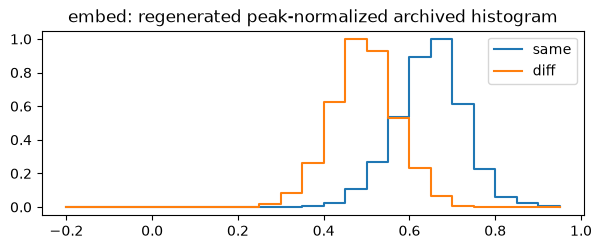

lsa same ARCHIVED median: 0.3512640595436096 computed fraction >= 0.6: 0.19017191541153203
hist_lsa_same_tail06 = 0.190171915412
lsa diff ARCHIVED median: -0.00955875450745225 computed fraction >= 0.6: 0.020659895377475625
hist_lsa_diff_tail06 = 0.0206598953775


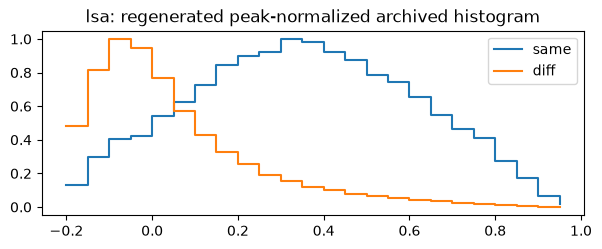

In [22]:
for representation in ['embed','lsa']:
    archive=FIXTURES['threshold_archive'][representation]
    bins=np.array(archive['bins'])
    for relationship in ['same','diff']:
        counts_hist=np.array(archive[relationship],float)
        peak_heights=counts_hist/max(1,counts_hist.max())
        tail_fraction=counts_hist[bins[:-1]>=.6].sum()/counts_hist.sum()
        assert_close(peak_heights.max(),1)
        print(representation,relationship,'ARCHIVED median:',archive[relationship+'_median'],'computed fraction >= 0.6:',tail_fraction)
        record_result('hist_'+representation+'_'+relationship+'_tail06',tail_fraction)
    fig,ax=plt.subplots(figsize=(7,2.4))
    for relationship in ['same','diff']:
        heights=np.array(archive[relationship],float);heights/=heights.max()
        ax.step(bins[:-1],heights,where='post',label=relationship)
    ax.set_title(representation+': regenerated peak-normalized archived histogram');ax.legend();plt.show()

## Episodes: threading across days

An *episode* is a chain of related stories across days. A story's *centroid* summarizes its member embeddings by their mean direction. In this subsection $t$ indexes calendar days, distinct from the earlier term index. A story on day $t$ continues yesterday's episode when its best centroid cosine against a story on day $t-1$ reaches **0.9**. Figure 16 shows, for 678 stories over eight day-pairs, each best previous-day cosine. With raw embeddings the median is 0.66 because unrelated news shares a common component. Reported continuations above the strict threshold include "Battle for Kyiv" after "Putin invasion deepens" (0.92), the Hamas attack's death toll two days running (0.90), and Brexit voters' portraits (0.93). In late February 2022, 21 of 1,077 stories continued an episode, and the longest, the invasion, ran fourteen days from 18 February to 3 March.

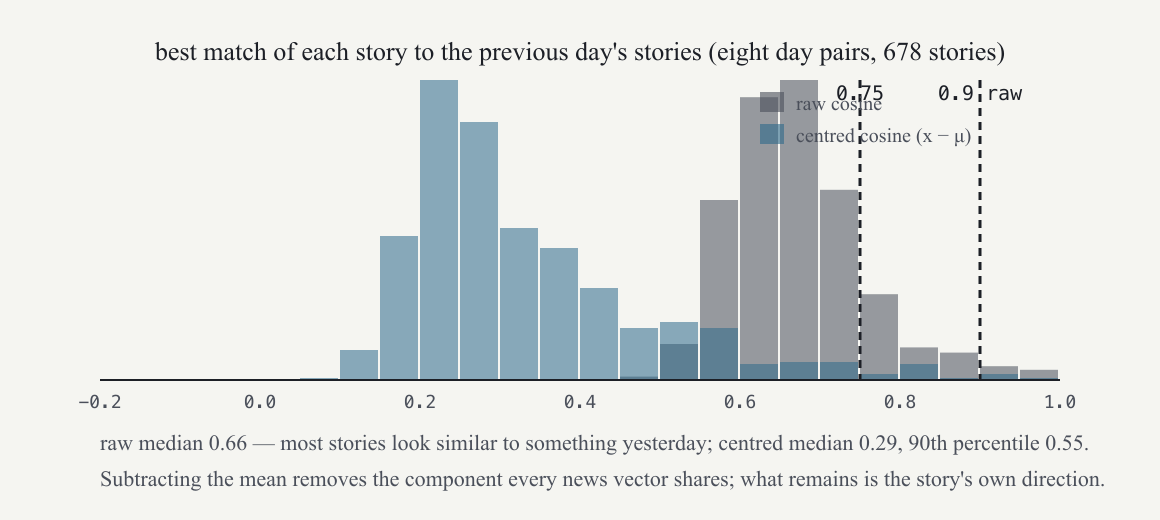

*Best previous‑day match per story, with raw and with centred cosines.*

Subtracting the mean first removes the common component and lowers the median to 0.29, with a sparser region around 0.55–0.75. A centred threshold near 0.75 is a candidate for separate evaluation, not a direct replacement proved by the figure. It would still miss the cited Crimea continuation at 0.69; lowering it enough to include that pair could also admit the unrelated New Zealand protest and abortion pair at 0.70. *Precision* is the share of accepted links that are correct, distinct from how many true continuations are recovered. The strict raw rule favours precision. An episode is a thread, not a day: "episode day 7" counts from the chain's beginning, and an archetype's canon counts episodes rather than repeated days.

### Laboratory: Best matches, thresholds and precision on labeled fixtures

`previous` and `current` are synthetic unit centroid rows. Each current row picks
its best previous-day cosine before the 0.9 threshold is applied. Separately,
`candidate_scores` and `is_true_link` form an explicit miniature labeled set to
compute precision and recall at alternative thresholds. Those labels are teaching
inputs, not judgments about the historical examples above. A new episode starts
when no previous match is accepted.

In [23]:
previous=np.eye(2);current=np.array([[.92,np.sqrt(1-.92**2)],[.7,np.sqrt(1-.7**2)]])
best_scores=(current@previous.T).max(1);accepted=best_scores>=.9
assert list(accepted)==[True,False]
candidate_scores=np.array([.92,.9,.93,.7,.69]);is_true_link=np.array([True,True,True,False,True])
for threshold in [.9,.75,.69]:
    predicted=candidate_scores>=threshold;tp=np.sum(predicted&is_true_link)
    print(threshold,'precision',tp/max(1,predicted.sum()),'recall',tp/is_true_link.sum())
record_result('strict_episode_links',accepted.sum())

0.9 precision 1.0 recall 0.75
0.75 precision 1.0 recall 0.75
0.69 precision 0.8 recall 1.0
strict_episode_links = 1


### Laboratory: Recompute the raw-versus-centered archived comparison

Figure 16's **frozen aggregate** contains 678 best-match scores summarized in
bins for raw and centered embeddings. We normalize each histogram to its own
peak and compute cumulative fractions below the bin edge 0.55. The displayed
0.66 and 0.29 medians remain archived metadata; binned counts alone would locate
only an interval containing each median. This comparison does not establish a
replacement production threshold or regenerate neural embeddings.

episode_raw_below055 = 0.0339233038348
raw ARCHIVED median: 0.6606759428977966 computed fraction below 0.55: 0.03392330383480826
episode_centered_below055 = 0.899705014749
centered ARCHIVED median: 0.28916847705841064 computed fraction below 0.55: 0.8997050147492626


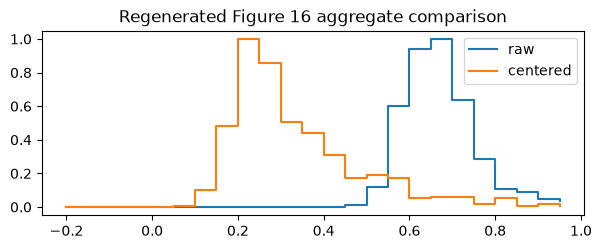

In [24]:
archive=FIXTURES['episode_archive'];bins=np.array(archive['bins'])
for representation in ['raw','centered']:
    values=np.array(archive[representation],float)
    assert values.sum()==archive['n']
    fraction=values[bins[1:]<=.55].sum()/values.sum()
    record_result('episode_'+representation+'_below055',fraction)
    print(representation,'ARCHIVED median:',archive[representation+'_median'],'computed fraction below 0.55:',fraction)
fig,ax=plt.subplots(figsize=(7,2.4))
for representation in ['raw','centered']:
    values=np.array(archive[representation],float);ax.step(bins[:-1],values/values.max(),where='post',label=representation)
ax.legend();ax.set_title('Regenerated Figure 16 aggregate comparison');plt.show()

## Precedents

The precedents of a story are the five closest earlier stories with the same dominant axis, by cosine of named‑axis coordinates, restricted to *distinct* episodes so that the five are five different wars, not five days of one. No threshold is needed: it is a ranking, and the cosine is printed beside each precedent (0.97 for the same week's build‑up briefing; 0.93 for Crimea in 2014) so the reader can see how close "closest" is.

### Laboratory: Select only eligible earlier stories

The tuples below carry an integer day, dominant-axis ID, episode ID and similarity to a
query on day 10 with dominant axis 0. We filter by time and axis, then keep only
the strongest entry per distinct episode, before taking the five closest. A very similar future story and a different-axis story must
not leak into the precedent list. Scores here are editable fixtures.

In [25]:
precedent_candidates=[(3,0,'a',.8),(11,0,'future',.99),(4,1,'other',.95),(7,0,'a',.7),(1,0,'b',.9),(9,0,'c',.6),(2,0,'d',.75),(8,0,'e',.65)]
eligible=sorted((row for row in precedent_candidates if row[0]<10 and row[1]==0),key=lambda row:-row[3])
seen_episodes=set();precedents=[]
for row in eligible:
    if row[2] not in seen_episodes:precedents.append(row);seen_episodes.add(row[2])
precedents=precedents[:5]
assert len(precedents)==5 and len({row[2] for row in precedents})==5
assert all(day<10 and axis==0 for day,axis,_,_ in precedents)
print('earlier same-axis top five:',precedents)
record_result('best_precedent_similarity',precedents[0][3])

earlier same-axis top five: [(1, 0, 'b', 0.9), (3, 0, 'a', 0.8), (2, 0, 'd', 0.75), (8, 0, 'e', 0.65), (9, 0, 'c', 0.6)]
best_precedent_similarity = 0.9


# The statistical thresholds

## ±2σ on the spectrum

An axis is *loud* or *silent* when its spectrum value lies more than two era standard deviations above or below its all-loaded-days mean. The symbol $\sigma$ in this heading means that reference standard deviation. For a Gaussian, or normal bell-shaped distribution, roughly one observation in twenty lies outside two standard deviations. Heavy-tailed news series need not have that frequency, and inspecting many axes changes the chance that at least one is flagged. The empirical intent is that a typical day lights one to three axes, not ten. On 24 February 2022 the Ukraine axis was at $+8$; on 12 September 2001 terrorism was at $+2.9$, Europe at $+2.6$, markets at $+2.5$. These numbers are spectrum z-scores, not probabilities.

### Laboratory: Welford statistics and the multiple-axis caveat

`era_values` is a small synthetic all-loaded-day reference, not a historical
forecast. We compute count, running mean, and squared-deviation accumulator
using Welford's update, then the **sample** standard deviation. A new value's
z-score is compared to ±2; a value below −2 belongs to Silence. The Gaussian
calculation is an illustration: multiplying the two-sided tail probability by
60 gives an expected number of flagged axes, not a calibrated newspaper alarm.

In [26]:
era_values=np.array([-1.,0.,1.,2.,3.]);count=0;running_mean=0.;m2_sum=0.
for value in era_values:
    count+=1;delta=value-running_mean;running_mean+=delta/count;m2_sum+=delta*(value-running_mean)
era_sd=np.sqrt(m2_sum/(count-1));assert_close(era_sd,era_values.std(ddof=1))
z_score=(-3.-running_mean)/era_sd
assert z_score < -2
normal_tail_2=1-math.erf(2/np.sqrt(2))
record_result('era_sample_sd',era_sd);record_result('silence_zscore',z_score);record_result('gaussian_expected_flags_60',60*normal_tail_2)

era_sample_sd = 1.58113883008
silence_zscore = -2.52982212813
gaussian_expected_flags_60 = 2.73001583378


## 1.5σ for "different this time"

A story is *different* from its archetype on an axis when its coordinate departs from the archetype's profile by more than 1.5 profile standard deviations; at most three such axes are shown, largest first. The line is lower than the spectrum's because the question is different: the spectrum asks whether the *day* is unusual, the delta panel asks whether *this instance* is an unusual member of its class, and a 1.5σ departure on a specific secondary axis—*airline · airport* on a terrorism story, at $+3.2\sigma$—is exactly the kind of thing a reader wants pointed out. With 59 secondary axes, a 1.5σ line would flag several by chance on every story if departures were independent Gaussians; they are not (the coordinates of an archetype's members are strongly correlated), and in practice the panel is empty for a textbook instance, which is the honest output for the invasion story: *nothing beyond 1.5σ of this archetype's profile*.

### Laboratory: Compute departures and cap the displayed list

`profile_mean` and `profile_sd` describe a synthetic archetype reference.
`story_named` is an instance. We standardize departures, keep magnitudes strictly
larger than 1.5, sort largest first and take at most three. The zero-departure
case produces an empty list. The expected Gaussian count over 59 secondary
axes explains why a threshold is not an automatic significance certificate.

In [27]:
profile_mean=np.array([1.,2.,0.,-1.]);profile_sd=np.array([1.,.5,2.,1.]);story_named=np.array([1.2,3.6,-4.,-.8])
departures=(story_named-profile_mean)/profile_sd
changed=sorted((j for j,z in enumerate(departures) if abs(z)>1.5),key=lambda j:-abs(departures[j]))[:3]
assert changed==[1,2]
assert np.sum(np.abs((profile_mean-profile_mean)/profile_sd)>1.5)==0
print('axis IDs and departures:',[(j,departures[j]) for j in changed])
record_result('largest_profile_departure',departures[changed[0]])
record_result('gaussian_profile_false_flags',59*(1-math.erf(1.5/np.sqrt(2))))

axis IDs and departures: [(1, np.float64(3.2)), (2, np.float64(-2.0))]
largest_profile_departure = 3.2
gaussian_profile_false_flags = 7.88324974973


## Energy × (1 + ν) for ranking

Stories are ranked by $\varepsilon_s(1+\nu_s)$: story $s$'s source-and-article-count energy times one plus its mean article novelty ratio. Thus an equally energetic story with more residual variation ranks higher. The residual section orders by $\nu_s$ itself. A large residual is a property of this representation, not independent evidence of newsworthiness.

### Laboratory: Attention-adjusted novelty ranking

`novelties` gives stipulated mean member-article novelty ratios for the three
stories from the spectrum fixture. Multiplying attention by one plus novelty
changes ordering without making novelty an independent truth or importance
score. Equal attention with novelty one doubles the zero-novelty rank score.

In [28]:
novelties=np.array([0.,.8,.2]);rank_scores=attention*(1+novelties)
print('attention:',attention,'rank scores:',rank_scores,'descending IDs:',np.argsort(-rank_scores))
assert_close(3*(1+1)/3,2)
record_result('maximum_rank_score',rank_scores.max())

attention: [2.772589 0.693147 5.375278] rank scores: [2.772589 1.247665 6.450334] descending IDs: [2 0 1]
maximum_rank_score = 6.45033408922


## 0.8 for matching axes across nights

When the basis is refitted, an assignment pairs new and old eigenvectors to maximize total absolute cosine, written $|\cos|$ (§10). Taking the absolute value makes this comparison insensitive to a direction's arbitrary sign. A match below 0.8 is rejected: the component is treated as a new archetype, while retirement uses the separate noise-edge rule. Reported well-separated axes match at 0.99+ between nights. The 0.8 value is an operational threshold, not a proof of identity between axes; poorly separated directions can move while their common subspace stays similar.

### Laboratory: Reject weak matches without confusing signs

The columns of `old_axes` are the coordinate basis. `new_axes` rotates two of
them by 0.2 radians and reverses one sign. Absolute cosine treats a sign flip as
the same line; the 0.8 threshold is then applied after matching. A 0.7 candidate
is rejected. This operational rule does not establish semantic identity.

In [29]:
old_axes=np.eye(2);new_axes=rotation_matrix(.2)@np.diag([-1.,1.])
absolute_matches=np.abs(old_axes.T@new_axes)
assert np.all(np.diag(absolute_matches)>.8);assert .7<.8
record_result('nightly_absolute_match',absolute_matches[0,0]);print(absolute_matches)

nightly_absolute_match = 0.980066577841
[[0.980067 0.198669]
 [0.198669 0.980067]]


# Matching axes

## Kuhn–Munkres

Two sets of axes are matched by an *assignment problem*: choose a one-to-one pairing maximizing total similarity. The Hungarian algorithm (Kuhn–Munkres) solves it in *polynomial time*, meaning the required work grows no faster than a fixed power of the problem size. For nightly comparisons in the same feature space, similarity is absolute eigenvector cosine; signs are then oriented to agree. Different feature spaces cannot be compared by their raw vector dot products. The notation $\mathbb R^d$ means lists of $d$ real-number coordinates; term and embedding directions here live in $\mathbb R^{50{,}000}$ and $\mathbb R^{384}$. Instead compare their scores on the same 100,000 stories by *correlation*: covariance of two score columns divided by their positive standard deviations. Figure 17 shows selected matched axes, including Ukraine paired with Ukraine at 0.67 and courts with courts at 0.62. The reported comparisons also include the EU at 0.57.

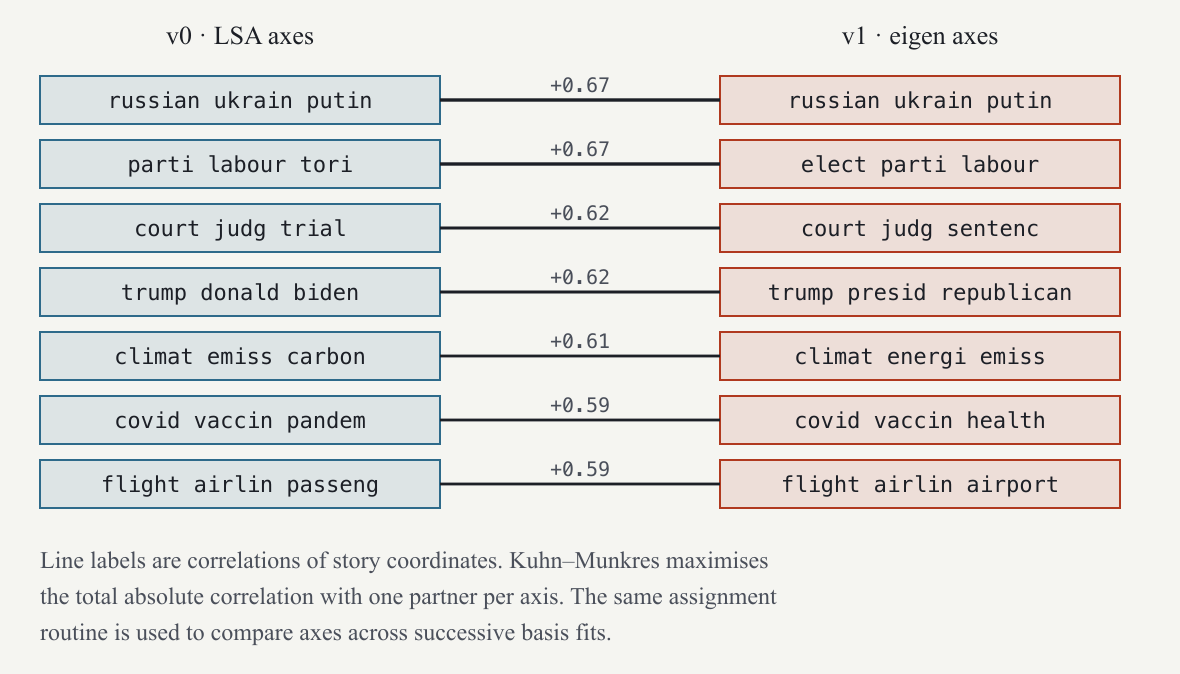

*Axes of the two bases paired by correlation of story coordinates.*

### Laboratory: Solve a global assignment, then compare score correlations

`similarity` is a synthetic 3 by 3 pairing table. A locally greedy first choice
loses to the globally optimal assignment. Python calls SciPy's assignment
routine; OCaml implements the Hungarian augmenting-path algorithm natively.
`story_scores_a` and `story_scores_b` are paired measurements of the same five
stories. Their correlation table supplies a comparable space even when the
underlying term and embedding basis directions have different dimensions.
The historical 0.67/0.62 figure labels are dated observations; these synthetic
scores do not re-estimate those unavailable 100,000-story measurements.

In [30]:
from scipy.optimize import linear_sum_assignment
similarity=np.array([[.9,.8,.1],[.85,.2,.1],[.1,.1,.95]])
assigned_rows,assigned_cols=linear_sum_assignment(-similarity)
optimal_total=similarity[assigned_rows,assigned_cols].sum()
assert_close(optimal_total,2.6);assert optimal_total>(.9+.2+.95)
record_result('assignment_total',optimal_total)
story_scores_a=np.array([[1,0],[2,1],[3,-1],[4,1],[5,0.]],float)
story_scores_b=np.column_stack([-story_scores_a[:,1],story_scores_a[:,0]])
ca=story_scores_a-story_scores_a.mean(0);cb=story_scores_b-story_scores_b.mean(0)
correlations=(ca.T@cb)/np.outer(np.linalg.norm(ca,axis=0),np.linalg.norm(cb,axis=0))
assert_close(abs(correlations[0,1]),1)
print('assignment:',list(zip(assigned_rows,assigned_cols)),'\nscore correlations:',correlations)
record_result('cross_basis_matched_correlation',abs(correlations[0,1]))

assignment_total = 2.6
assignment: [(np.int64(0), np.int64(1)), (np.int64(1), np.int64(0)), (np.int64(2), np.int64(2))] 
score correlations: [[ 0.  1.]
 [-1.  0.]]
cross_basis_matched_correlation = 1


## Why nightly refinement is stable

The Davis–Kahan theorem relates changes in a symmetric matrix to changes in its separated eigendirections. Let $E$ be the change in covariance and let $\varepsilon=\lVert E\rVert_2$ be its *spectral norm*, the greatest output length $E$ produces from a unit input. For a matched simple old eigenvalue and a new one, let $g>0$ be the distance from that new eigenvalue to every *other* old eigenvalue, taking the smallest such distance. A simple eigenvalue has a one-dimensional eigenspace. Let $\theta$ be the acute angle between their unit eigenvectors, after matching signs. Then $\sin\theta\le\varepsilon/g$; the sine measures the perpendicular component of the turning direction. This precise separation condition matters: an arbitrarily chosen nearest-neighbour gap cannot be substituted without further assumptions. Small gaps weaken the guarantee, and degenerate groups call for comparing subspaces.

If the added day's total weight and observation lengths stay bounded while accumulated weight grows in proportion to an observation count $N$, the one-step covariance change can be $O(1/N)$. Big-O notation here means bounded by a constant times $1/N$ under those assumptions. This controls an individual update; it does not by itself prove that an evolving news basis converges forever. *Procrustes alignment* rotates or reflects matched directions within a group to minimize their squared differences. *Warm-starting* begins the new varimax search from the preceding rotation. These can help continuity, but cannot guarantee it when data or eigengaps change substantially.

### Laboratory: Check Davis–Kahan and align a rotated subspace

`old_cov` is a separated 2 by 2 covariance; `perturbation` changes its off-diagonal
entries. `epsilon` is the spectral norm of that change. `gap` is specifically the
distance from the new leading eigenvalue to the *other old eigenvalue*, matching
the theorem's stated hypothesis. We compare the actual sine of the angle with
the bound. Then Procrustes alignment undoes a synthetic rotation of a subspace;
the aligned projectors agree even if individual unaligned columns differ.

In [31]:
old_cov=np.diag([3.,1.]);perturbation=np.array([[0.,.05],[.05,0.]])
new_values,new_vectors=np.linalg.eigh(old_cov+perturbation)
new_leader=new_vectors[:,-1];epsilon=np.linalg.norm(perturbation,2);gap=abs(new_values[-1]-1)
sin_theta=np.sqrt(max(0,1-abs(new_leader[0])**2))
assert sin_theta<=epsilon/gap+1e-12
record_result('davis_kahan_sine',sin_theta);record_result('davis_kahan_bound',epsilon/gap)
subspace=np.eye(3)[:,:2];rotated_subspace=subspace@rotation_matrix(.6)
pu,_,pvt=np.linalg.svd(rotated_subspace.T@subspace)
alignment=pu@pvt
assert_close(rotated_subspace@alignment,subspace)
assert_close(rotated_subspace@rotated_subspace.T,subspace@subspace.T)
print('alignment:',alignment)

davis_kahan_sine = 0.0249766002706
davis_kahan_bound = 0.0249843945008
alignment: [[ 0.825336  0.564642]
 [-0.564642  0.825336]]


# Streaming the computation

The first edition of Eigen Times was fitted on 1.09 million articles, and its code could afford to hold what it needed: every article's embedding and coordinates while the axes were oriented, and the whole document–term matrix while the axes were named. The second edition ingested the *New York Times* archive back to 1851 and multiplied the corpus by fifteen, to 16.5 million articles. The first attempt to fit it was killed by the operating system at about forty gigabytes. What follows is the arithmetic that let the same computation run in a fraction of a gigabyte—not a bigger machine, but a change of shape. The principle is one sentence: *every quantity the fit needs is a sum over documents, and a sum can be taken in blocks.*

## Weights that balance the days

Before the sums, the weights. By article count the modern era dominates the archive—the Guardian alone publishes about as many articles a day as the *Times* index ever recorded—while by the calendar it is fifteen per cent of 175 years. Let $i$ index articles and $\tau$ a calendar day. Write $\tau(i)$ for article $i$'s day and $n_\tau>0$ for the number of eligible articles on that day. The second edition assigns article $i$ the inverse-count weight $w_i$. A sum constrained by $\tau(i)=\tau$ includes only articles from the chosen day:

$$w_i = 1 / n_{\tau(i)}, \qquad \sum_{\tau(i) = \tau} w_i = 1,$$

Every populated day therefore contributes one unit to the fit: a day in 1887 with 40 index entries and a day in 2024 with 900 articles count the same. Total weight $Z$ is the number of represented days, 63,270. The covariance formulas retain their shapes; the diagonal entries of $W$ change. For term-space fitting, let $\mu_{T,w}$ be the $p\times1$ TF‑IDF mean under these same article weights. With $T$ of shape $N\times p$ and $\mathbf1$ of length $N$, the balanced LSA fit decomposes $W^{1/2}(T-\mathbf1\mu_{T,w}^{\top})$. Its mean is distinct from the unweighted naming mean $\mu_T$ below.

### Laboratory: Forty historical and nine hundred modern articles

We compute, rather than assume, that forty weights of 1/40 and nine hundred
weights of 1/900 give one unit per populated day. For a two-day synthetic vector
fixture the daily-weighted mean differs from the unweighted article mean.
`weighted_terms` multiplies centered rows by square-root weights, preparing the
weighted LSA operator.

In [32]:
day_ids=np.repeat([0,1],[40,900]);day_weights=1/np.bincount(day_ids)[day_ids]
assert_close([day_weights[day_ids==d].sum() for d in [0,1]],[1,1])
two_day_rows=np.column_stack([day_ids,np.ones(len(day_ids))]).astype(float)
daily_mean,daily_cov=covariance(two_day_rows,day_weights)
weighted_terms=np.sqrt(day_weights)[:,None]*(two_day_rows-daily_mean)
assert_close(weighted_terms.T@weighted_terms/day_weights.sum(),daily_cov)
record_result('day_balanced_mean',daily_mean[0]);print('article mean:',two_day_rows.mean(0),'balanced mean:',daily_mean)

day_balanced_mean = 0.5
article mean: [0.957447 1.      ] balanced mean: [0.5 1. ]


## Sums over blocks

Split the article rows into disjoint blocks indexed by $b=1,2,\ldots$. In Eigen Times, a block is one source's articles for one month; there are about three thousand. The notation $i\in b$ means article row $i$ belongs to block $b$. Let $g$ be any fixed rule converting a row $x_i$ into a scalar, vector, or matrix contribution of the same shape for every row. Then $\sum_i g(x_i)=\sum_b\sum_{i\in b}g(x_i)$: calculate each block's partial sum, add it, and discard the block. Here the function $g$ is unrelated to the eigengap scalar in §10.

A *thread* is a worker executing part of the computation; an *accumulator* stores its partial total. Workers can merge partial sums because addition commutes in exact arithmetic. Floating-point arithmetic can introduce small order-dependent rounding differences. Memory is bounded by the largest block plus these accumulators. The covariance's $Z,m,M$ are *sufficient summaries* for reconstructing that mean and covariance; the phrase does not claim they retain all information about the articles. Two other stages needed the same treatment.

### Laboratory: Merge covariance sufficient summaries

Each block contributes total weight, weighted coordinate sum and weighted outer
product sum. Two partitions of the earlier seven-row covariance example give
the same mean and covariance as its batch calculation. These summaries preserve
those statistics, not all information about the documents.

In [33]:
block_summaries=[]
for indices in [np.arange(3),np.arange(3,7)]:
    xb=covariance_rows[indices];wb=weights[indices]
    block_summaries.append((wb.sum(),wb@xb,xb.T@(wb[:,None]*xb)))
merged_z=sum(a for a,_,_ in block_summaries);merged_m=sum(b for _,b,_ in block_summaries);merged_M=sum(c for _,_,c in block_summaries)
merged_mu=merged_m/merged_z;merged_cov=merged_M/merged_z-np.outer(merged_mu,merged_mu)
assert_close(merged_cov,cov);record_result('streaming_covariance_error',np.linalg.norm(merged_cov-cov))

streaming_covariance_error = 6.28266935388e-16


## Orienting an axis from power sums

Fix one raw axis $j$ and let $c_{ij}$ be article $i$'s score on it. Let $n>0$ count the articles in this orientation pass and let $\bar c_j$ be their unweighted mean score; an overbar denotes a mean. The third central moment is $m_3=n^{-1}\sum_i(c_{ij}-\bar c_j)^3$, where $n^{-1}=1/n$. Its negative sign tells the orientation rule to flip the axis. The old pass retained 16.5 million scores for each axis. Instead define three *power sums*, sums of first, second, and third powers:

$$n, \qquad S_1 = \sum_i c_{ij}, \qquad S_2 = \sum_i c_{ij}^2, \qquad S_3 = \sum_i c_{ij}^3,$$

These scalar $S_1,S_2,S_3$ are distinct from the naming-score matrix $S$. For this one axis, abbreviate $\bar c_j$ as $\bar c=S_1/n$. Expanding the square and cube expresses the second and third central moments using only those sums:

$$m_2=S_2/n-\bar c^2,$$
$$m_3=S_3/n-3\bar c\,S_2/n+2\bar c^3.$$

Four numbers per axis—$n$ and three sums—replace the column. Each partition adds its documents' powers to an accumulator; accumulators merge by adding those four numbers. These polynomial identities are exact, but subtracting nearly equal floating-point values can lose precision when the mean is large compared with the spread. The reported tests compare streaming and batch orientation signs, including merged partial accumulators; they do not make that numerical risk disappear for arbitrary data.

### Laboratory: Recover moments from four mergeable numbers

The same signed-score fixture now passes through two blocks. Each produces the
count and sums of first, second and third powers. Their merged polynomial
formula must equal direct centered moments. These equalities concern arithmetic;
a huge offset can still cause cancellation in floating-point power sums.

In [34]:
powers=sum(np.array([len(block),block.sum(),np.sum(block**2),np.sum(block**3)]) for block in np.array_split(signed_scores,2))
number,s1,s2,s3=powers;score_average=s1/number
power_m2=s2/number-score_average**2;power_m3=s3/number-3*score_average*s2/number+2*score_average**3
assert_close(power_m2,m2);assert_close(power_m3,m3)
record_result('power_sum_third_moment',power_m3)

power_sum_third_moment = -12.384


## Term loadings block by block

Recall that $T$ has $N$ article rows and $p$ TF‑IDF columns, $\mu_T$ is their unweighted $p\times1$ mean, and $S$ has the matching $N$ rows of $k$ whitened raw scores. Its row order must agree with $T$. The $p\times k$ term-loading matrix $\beta$ is the centred term–score cross-product. Expanding it gives

$$\beta=T^{\top}S-\mu_T(\mathbf1^{\top}S).$$

Let $N_b$ count articles in block $b$, and let $T_b$ and $S_b$ contain its matching rows, with shapes $N_b\times p$ and $N_b\times k$. Write $\mathbf1_b$ for the $N_b\times1$ column of ones, while $\mathbf1$ without a subscript has length $N$. Then

$$T^{\top}S=\sum_b T_b^{\top}S_b,\qquad \mathbf1^{\top}S=\sum_b\mathbf1_b^{\top}S_b,$$
$$\mu_T=N^{-1}\sum_b T_b^{\top}\mathbf1_b.$$

So each block contributes three small things: a $p \times k$ matrix ($50{,}000 \times 60$, twenty-four megabytes), the column sums of its term rows ($p$ numbers) and the column sums of its scores ($k$ numbers). The block itself—the sparse rows of one month's articles and their scores—is built, folded in, and dropped (Figure 18). The full $T$, which has 455 million non-zero entries for the 175-year corpus and was being held *twice* by the batch code, never exists in the naming pass. At the end the three accumulated pieces are combined by the formula above; a property test checks that the result equals the whole-matrix operator applied to the concatenated blocks, to $10^{-12}$.

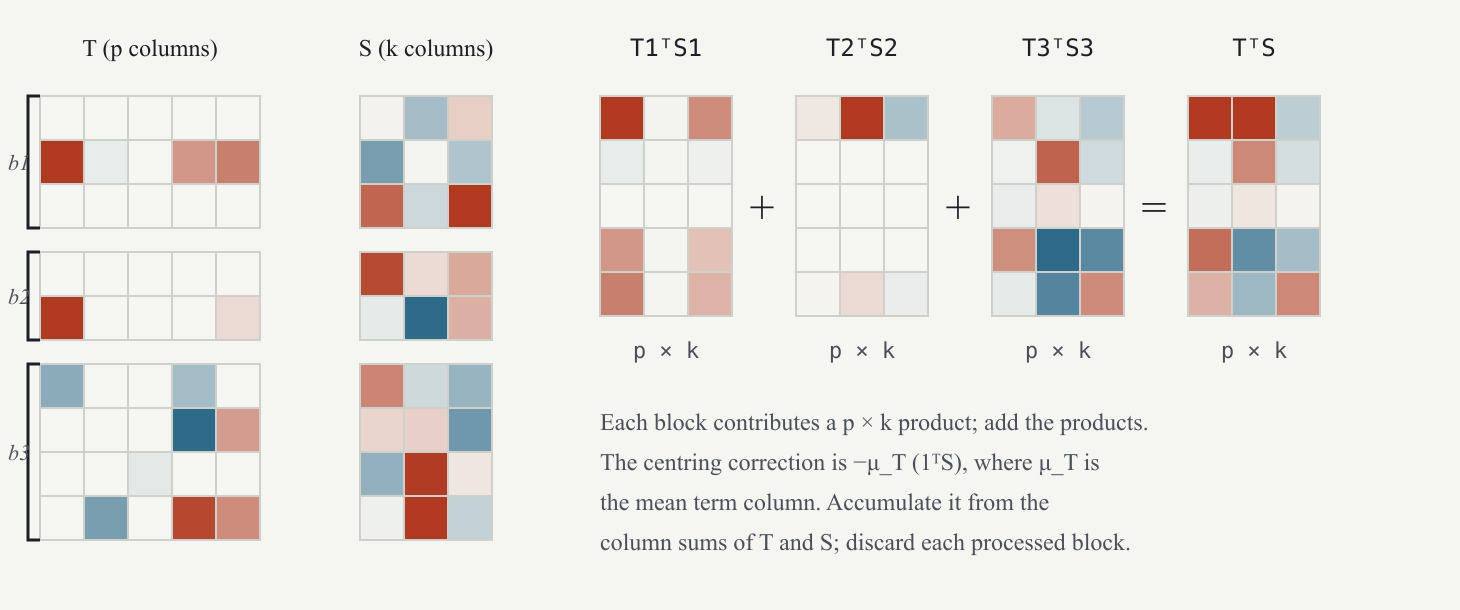

*Term loadings block by block: each block of documents contributes one small $p \times k$ matrix, and the sum is the whole.*

The same pass over a block also projects its embeddings to coordinates and computes $T^2$, $Q$ and $\nu$ for its documents, writing them to the partition's own table. The whole eigen fit is thus three passes over the archive—covariance, orientation, measurement—each of which reads one partition at a time. On 16.5 million articles it runs in ten minutes and stays at 0.3 GB of memory.

### Laboratory: Recompute Figure 18 and its centering correction

The three term and score blocks are the exact raw synthetic inputs generated by
Figure 18's seed-7 recipe. Each partial product has shape 5 by 3. `raw_cross` is
their sum. `centered_cross` additionally subtracts the outer product of the term
mean and score sums. We verify equality with concatenating all rows and directly
centering, to the manuscript's 10⁻¹² comparison scale.

In [35]:
raw_cross=sum(t.T@s for t,s in zip(term_blocks,score_blocks))
term_total=sum(t.sum(0) for t in term_blocks);score_total=sum(s.sum(0) for s in score_blocks);n_rows=sum(len(t) for t in term_blocks)
centered_cross=raw_cross-np.outer(term_total/n_rows,score_total)
all_terms=np.vstack(term_blocks);all_scores=np.vstack(score_blocks)
batch_cross=(all_terms-all_terms.mean(0)).T@all_scores
assert_close(centered_cross,batch_cross,tol=1e-12)
print('raw cross-product:',raw_cross,'\ncentered:',centered_cross)
record_result('streaming_loadings_norm',np.linalg.norm(centered_cross));record_result('streaming_loadings_error',np.linalg.norm(centered_cross-batch_cross))

raw cross-product: [[-1.651423 -1.650793  0.46894 ]
 [ 0.094993 -0.948057  0.268621]
 [ 0.066168 -0.131554 -0.010077]
 [-1.178152  1.220516  0.663776]
 [-0.579993  0.729684 -0.950176]] 
centered: [[-1.925555 -1.551565  0.261532]
 [ 0.348501 -1.03982   0.460424]
 [ 0.099814 -0.143733  0.015379]
 [-1.125416  1.201427  0.703676]
 [-1.162265  0.94045  -1.390723]]
streaming_loadings_norm = 3.87344949371
streaming_loadings_error = 4.745190132e-16


## Stories one month at a time

Clustering into stories (chapter *The clustering thresholds*) is done within a day, and threading into episodes links a day's stories to the previous day's. So the dependency of day $\tau$ is on the articles of $\tau$ and the stories of $\tau - 1$, nothing else: the days form a chain. The batch code loaded every article's vector and title before starting; the streaming version walks the months in order, loads one month's articles, clusters its days in sequence, carries the last day's stories across the month boundary, writes the month's stories and drops the month. Memory is one month of articles instead of 175 years of them.

### Laboratory: Carry episode state across a block boundary

Six synthetic daily story centroids rotate slightly, then jump to another
region. A function threads them with the 0.9 rule while retaining only the
previous centroid and current episode ID. Processing all six days or processing
two artificial month blocks must give identical episode IDs.

In [36]:
daily_angles=np.array([0.,.05,.1,1.5,1.55,1.6]);daily_centroids=np.column_stack([np.cos(daily_angles),np.sin(daily_angles)])
def thread_days(days,state=(None,-1)):
    previous,episode=state;ids=[]
    for current in days:
        if previous is None or cosine(previous,current)<.9:episode+=1
        ids.append(episode);previous=current
    return ids,(previous,episode)
batch_ids,_=thread_days(daily_centroids)
first_ids,carry=thread_days(daily_centroids[:3]);second_ids,_=thread_days(daily_centroids[3:],carry)
assert batch_ids==first_ids+second_ids==[0,0,0,1,1,1]
print('episode IDs across boundary:',batch_ids);record_result('streamed_episode_count',len(set(batch_ids)))

episode IDs across boundary: [0, 0, 0, 1, 1, 1]
streamed_episode_count = 2


## What still has to fit in memory

Two stages remain large. Randomized LSA uses a $p\times l$ working matrix $\Omega$ and products such as $T\Omega$ and $T^{\top}(T\Omega)$, together with the centering and weighting corrections described in §5. The first product can be emitted by row block; the second is a sum of block cross-products. This avoids requiring all of $T$ at once, although working score matrices also need a storage plan. In the reported edition the 455-million-nonzero matrix remains in memory: 31 GB on a 64 GB laptop. The block form is a next step, not a claimed implementation. The other large object is the site index, which retains story centroids and profiles for precedents: about 20 GB for 13.4 million stories. These retained objects determine the second edition's build-machine requirement.

| pass | before | after |
|---|---|---|
| eigen: orientation | every vector and coordinate (≈30 GB) | four power sums per axis |
| eigen: term loadings | $T$ twice, plus $S$ (≈20 GB) | one $p \times k$ accumulator per thread (24 MB) |
| stories | every vector and title (≈25 GB) | one month at a time |
| LSA: randomized SVD | $T$ in memory (31 GB) | unchanged |
| site index | every story (20 GB) | unchanged |

### Laboratory: Calculate storage costs, without allocating the archive

Float64 entries occupy eight bytes; a decimal megabyte is one million bytes and
a gibibyte is 2³⁰ bytes. We calculate the 50,000 by 60 accumulator's 24 MB cost
and compare hypothetical dense archive tables. These are arithmetic estimates;
the reported 31 GB sparse LSA and 20 GB site index include implementation-specific
objects and cannot be inferred by multiplying a single shape alone.

In [37]:
accumulator_bytes=50_000*60*8;dense_term_bytes=16_500_781*50_000*8
print('term accumulator MB:',accumulator_bytes/1e6,'hypothetical dense term table GiB:',dense_term_bytes/2**30)
record_result('loading_accumulator_megabytes',accumulator_bytes/1e6)
assert accumulator_bytes==24_000_000

term accumulator MB: 24.0 hypothetical dense term table GiB: 6147.019937634468
loading_accumulator_megabytes = 24


# The pipeline as matrices

Figure 19 summarizes the stages. Here $N$ counts articles, $E$ is their $N\times384$ embedding matrix, $\mu$ is the embedding mean column, and $C=(E-\mathbf1\mu^{\top})V$ is the $N\times60$ table of raw coordinate rows. The term-space mean remains $\mu_T$, and $S$ denotes the standardized raw score rows used for lexical naming. The numerical decompositions are small—a $384\times384$ covariance, a $384\times60$ basis, a $50{,}000\times60$ loading table, and a $60\times60$ rotation—while the previous section identifies the large objects still retained in memory. The subscript "lsa" below identifies a basis fitted in term space.

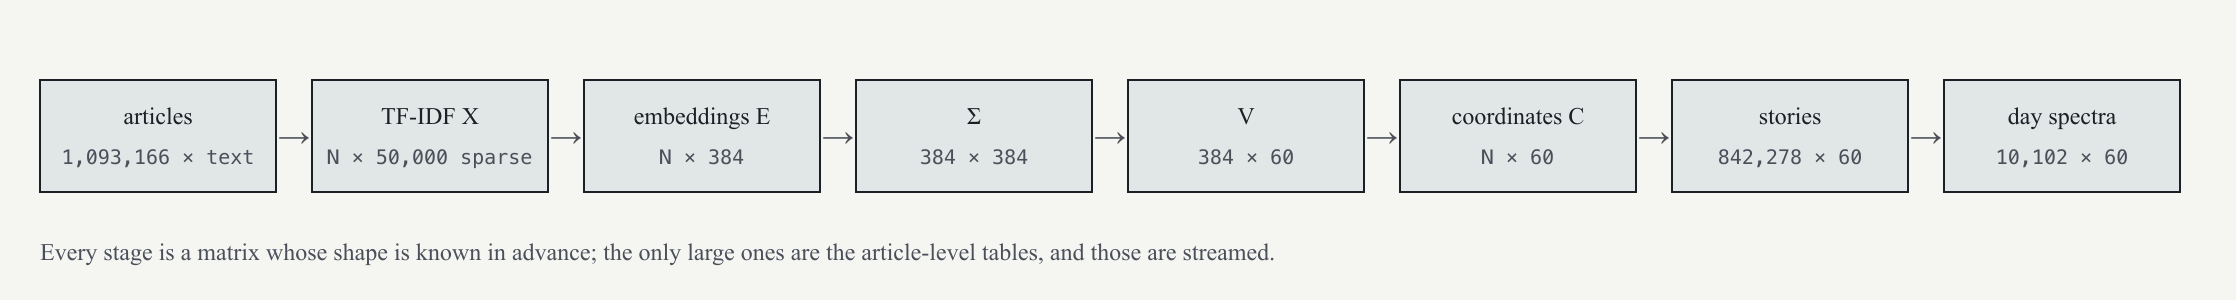

*The pipeline, stage by stage, as matrices.*

| stage | object | shape | operation |
|---|---|---|---|
| tokenise | TF‑IDF matrix $T$ | $N \times 50{,}000$, sparse | randomized SVD → $V_{\text{lsa}}$, $U$ |
| embed | $E$ | $N \times 384$ | streaming $Z, m, M$ |
| covariance | $\Sigma$ | $384 \times 384$ | `eigh` → $V, \Lambda$ |
| name | centred term–score product $\beta$ | $50{,}000 \times 60$ | varimax → $R$ |
| measure | $C = (E - \mathbf{1}\mu^{\top})V$ | $N \times 60$ | $T^2$, $Q$, $\nu$ per row |
| stories | centroids | $842{,}278 \times 60$ | profiles, precedents |
| days | spectra | $10{,}102 \times 60$ | era statistics, z‑scores |

The numbers in the table are those of the first edition on 28 August 2026; each grows by a day's worth every night. The second edition, fitted on 3 September 2026 over the *New York Times* archive as well, has $N = 16{,}500{,}781$ articles (455 million non-zeros in $T$), 13,421,090 stories and 63,270 day spectra; the small matrices—$\Sigma$, $V$, $\beta$, $R$—have exactly the same shapes, which is the point of the chapter *Streaming the computation*.

### Laboratory: Check shape contracts and dated totals

We build a complete tiny shape-compatible chain using six documents, seven
terms, three embedding coordinates and two retained axes. `toy_embeddings` are
explicit synthetic measurements, not neural embeddings. The shape checks show
how covariance, coordinates, whitened lexical naming and a rotation fit together.
The production counts in the prose retain their original 2026 edition dates.

In [38]:
toy_embeddings=np.array([[1,0,0],[2,1,0],[3,-1,1],[0,2,1],[1,3,-1],[2,1,2.]],float)
toy_mu,toy_cov=covariance(toy_embeddings,np.ones(6));toy_values,toy_vectors=np.linalg.eigh(toy_cov)
toy_basis=toy_vectors[:,::-1][:,:2];toy_values=toy_values[::-1][:2]
toy_coords=(toy_embeddings-toy_mu)@toy_basis;toy_whitened=toy_coords/np.sqrt(toy_values)
toy_beta=(tfidf-tfidf.mean(0)).T@toy_whitened;toy_rotation=rotation_matrix(.2)
assert toy_cov.shape==(3,3) and toy_basis.shape==(3,2) and toy_coords.shape==(6,2) and toy_beta.shape==(7,2)
assert_close(toy_whitened.T@toy_whitened/6,np.eye(2))
record_result('pipeline_coordinate_energy',np.sum(toy_coords**2))
print('E',toy_embeddings.shape,'covariance',toy_cov.shape,'V',toy_basis.shape,'C',toy_coords.shape,'beta',toy_beta.shape,'R',toy_rotation.shape)

pipeline_coordinate_energy = 18.7926192942
E (6, 3) covariance (3, 3) V (3, 2) C (6, 2) beta (7, 2) R (2, 2)


# Notation

| symbol | meaning |
|---|---|
| $x_i$, $w_i$ | article column vector and its covariance fit weight |
| $\mu$, $\Sigma$, $Z$ | weighted article mean, covariance, and total fit weight |
| $m$, $M$, $W$ | weighted vector sum, outer-product sum, and diagonal fit-weight matrix |
| $V$, $\Lambda$ | eigenvectors (columns) and eigenvalues of $\Sigma$; $k$ of them kept |
| $R$, $V' = VR$, $y=R^{\top}c$ | naming rotation, named directions, and named coordinate column |
| $c$, $\hat{x}$, $r$ | raw coordinates, reconstruction, residual of an observation column $x$ |
| $\Gamma=R^{\top}\Lambda R$ | covariance of the rotated raw coordinates; generally not diagonal |
| $T^2$, $Q$, $\nu$ | Hotelling's statistic, residual energy, novelty ratio |
| $T$, $\mu_T$, $S$, $\beta$ | TF‑IDF rows, their naming mean, whitened raw score rows, centred term–score loadings |
| $U$, $\Sigma_{\mathrm{svd}}$, $V$ | left directions, singular-value matrix, and right directions in the SVD context |
| $\sigma_j$ | singular values; $\lambda_j=\sigma_j^2/n$ for an equally weighted centred matrix |
| $\varepsilon_s$, $s_j$ | story attention energy; empirical named-axis standard deviation for dominance |
| $n_\tau$, $w_i = 1/n_{\tau(i)}$ | articles on day $\tau$ and the day-balanced weight of article $i$ |
| $T_b$, $S_b$, $N_b$ | term rows, score rows, and article count in block $b$ |
| $S_1, S_2, S_3$ | power sums of an axis's scores, from which its skewness sign is read |

# References

1. Deerwester, S., Dumais, S. T., Furnas, G. W., Landauer, T. K., & Harshman, R. (1990). Indexing by latent semantic analysis. *Journal of the American Society for Information Science*, 41(6), 391–407.
2. Eckart, C., & Young, G. (1936). The approximation of one matrix by another of lower rank. *Psychometrika*, 1(3), 211–218.
3. Halko, N., Martinsson, P.-G., & Tropp, J. A. (2011). Finding structure with randomness: Probabilistic algorithms for constructing approximate matrix decompositions. *SIAM Review*, 53(2), 217–288.
4. Hotelling, H. (1931). The generalization of Student's ratio. *Annals of Mathematical Statistics*, 2(3), 360–378.
5. Jackson, J. E., & Mudholkar, G. S. (1979). Control procedures for residuals associated with principal component analysis. *Technometrics*, 21(3), 341–349.
6. Kaiser, H. F. (1958). The varimax criterion for analytic rotation in factor analysis. *Psychometrika*, 23(3), 187–200.
7. Kuhn, H. W. (1955). The Hungarian method for the assignment problem. *Naval Research Logistics Quarterly*, 2(1–2), 83–97.
8. Davis, C., & Kahan, W. M. (1970). The rotation of eigenvectors by a perturbation. III. *SIAM Journal on Numerical Analysis*, 7(1), 1–46.
9. Marchenko, V. A., & Pastur, L. A. (1967). Distribution of eigenvalues for some sets of random matrices. *Mathematics of the USSR‑Sbornik*, 1(4), 457–483.
10. Welford, B. P. (1962). Note on a method for calculating corrected sums of squares and products. *Technometrics*, 4(3), 419–420.
11. Xiao, S., Liu, Z., Zhang, P., & Muennighoff, N. (2023). C‑Pack: Packaged resources to advance general Chinese embedding. arXiv:2309.07597.
12. Khrabrov, A. (2026). *Eigen Times: A Newspaper in the Eigenbasis of the News*. First Pair Press. https://firstpair.org/read/eigentimes/

### Laboratory: Reproducibility receipt and teaching checkpoint

The receipt below records values computed by the cells, not prefilled expected
answers. Python and OCaml should agree within numerical tolerance. Eigenvector
signs may differ, so comparison uses sign-invariant values. Every manuscript
section, including notation and references, remains in this notebook. Frozen
historical aggregates are evidence inputs; only the fully specified toy and
figure-input calculations are regenerated here. To teach interactively, change
a fixture and restart/run all, then explain which assertions should change and
which mathematical identities must still hold.

In [39]:
print('RESULT_JSON:'+json.dumps(RESULTS,sort_keys=True))

RESULT_JSON:{"archived_largest_fraction_072": 0.40789473684210525, "assignment_total": 2.5999999999999996, "best_precedent_similarity": 0.9, "cloud_lambda_1": 4.055287954936994, "cloud_lambda_2": 0.4378442025387127, "cloud_variance_fraction": 0.9025525652945185, "cosine_d2_d5": 1.0, "cross_basis_matched_correlation": 0.9999999999999998, "davis_kahan_bound": 0.024984394500785725, "davis_kahan_sine": 0.024976600270612367, "day_balanced_mean": 0.49999999999999, "discarded_projection_energy": 9.0, "episode_centered_below055": 0.8997050147492626, "episode_raw_below055": 0.03392330383480826, "era_sample_sd": 1.5811388300841898, "figure_covariance_trace": 4.537999371912012, "gaussian_expected_flags_60": 2.730015833781505, "gaussian_profile_false_flags": 7.883249749725254, "hist_embed_diff_tail06": 0.0806495368755571, "hist_embed_same_tail06": 0.7495454545454545, "hist_lsa_diff_tail06": 0.020659895377475625, "hist_lsa_same_tail06": 0.19017191541153203, "hotelling_t2": 2.0, "idf_ceasefire": 1.8